<a href="https://colab.research.google.com/github/matheussilvamendes9/Growing-Neural-Gas-para-Analise-de-Comportamento-Educacional/blob/main/GNG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
df = pd.read_csv("https://raw.githubusercontent.com/ect-comp/ml/refs/heads/master/dados/metricas_lop.csv")

# Classe do Growing Neural Gas ajustado com transições
class GrowingNeuralGas:
    def __init__(self, n_inputs, n_start_nodes=2, max_nodes=8, alpha=0.1, beta=0.001, multi = 100, epochs=100, Omega = 0.5, Delta = 0.0005,fracao_K = 0.00005):
        # Quantidade de caracteristicas
        self.n_inputs = n_inputs
        #Numero inicial de Nodes
        self.n_start_nodes = n_start_nodes
        #Numero maximo
        self.max_nodes = max_nodes
        #O quanto o node mais proximo se aproxima do dado
        self.alpha = alpha
        #o quanto os nodes vizinhos de movem em direção ao dado
        self.beta = beta
        self.multi= multi # Frequência de inserção (lambda)
        self.epochs = epochs
        #Decaimento do erro ao adicionar um novo nó
        self.Omega = Omega
        #Decaimento goblal do erro em cada Epoch
        self.Delta = Delta
        #Valor para definir se remove ou nao o nó
        self.fracao_K = fracao_K

        self.nodes = np.random.rand(self.n_start_nodes, n_inputs)
        self.errors = np.zeros(self.n_start_nodes)

        # Estrutura de Topologia: {nó_A: {nó_B: 0, nó_C: 0}, ...}
        self.Arestas = {i: {} for i in range(self.n_start_nodes)}
        if self.n_start_nodes >= 2:
            self.Arestas[0][1] = 0
            self.Arestas[1][0] = 0

        #Fator de Utilidade
        self.FU = np.zeros(self.n_start_nodes)
        self.transitions = []
        self.listaN = []

    def train(self, data, lista, neuronios, indices):
        self.transitions = lista.copy()
        self.listaN = neuronios.copy()
        num_dados = len(data)
        for epoch in range(self.epochs):
            k = 0   # posição esperada no conjunto original
            x = 0   # índice real no array "data"
            while x < num_dados:
                if np.isnan(data[x]).any() == False:

                    # 1. Busca BMU
                    data_point = data[x]
                    diff = self.nodes - data_point
                    dist_sq = np.sum(diff**2, axis=1)
                    sorted_indices = np.argsort(dist_sq)
                    bmu_idx = sorted_indices[0]
                    second_bmu_idx = sorted_indices[1]

                    # 2. Atualização do BMU e vizinhos (topológica)
                    self.nodes[bmu_idx] += self.alpha * (data_point - self.nodes[bmu_idx])

                    # Otimizado para vizinhos topológicos
                    lista_dos_ligados_ao_no = list(self.Arestas[bmu_idx].keys())
                    for ligado in lista_dos_ligados_ao_no:
                        self.nodes[ligado] += self.beta * (data_point - self.nodes[ligado])

                    # Reconecta BMU e SBMU
                    self.Arestas[bmu_idx][second_bmu_idx] = 0
                    self.Arestas[second_bmu_idx][bmu_idx] = 0

                    # 3. Erro acumulado e Fator de Utilidade
                    self.errors[bmu_idx] += dist_sq[bmu_idx]
                    self.FU[bmu_idx] += self.errors[bmu_idx] - self.errors[second_bmu_idx]


                    # 4. Inserção de Novo Nó
                    if (len(self.nodes) < self.max_nodes) and (x % self.multi == 0):
                        self.add_new_node()


                    # 5. Remoção por Fator de Utilidade
                    sorted_indices_FU = np.argsort(self.FU)
                    menor_FU_indice = sorted_indices_FU[0]
                    if np.max(self.errors) > 0 and (self.FU[menor_FU_indice] / np.max(self.errors)) < self.fracao_K and (len(self.nodes) > 2):
                      self.remove_node(menor_FU_indice)

                    # 6. Registro de transição no último epoch
                    if epoch == self.epochs - 1:
                        while len(self.transitions) <= k:
                            self.transitions.append([])
                        self.transitions[k].append(int(bmu_idx))
                        if len(self.transitions[k]) >= 2:
                            ultimos = self.transitions[k][-2:]
                            if "vazio" not in ultimos:
                                transicao = [ultimos[0], ultimos[1]]
                                tem = False
                                for n in range(len(self.listaN)):
                                    if (self.listaN[n][0] == transicao and self.listaN[n][2] == len(self.transitions[k])):
                                        self.listaN[n][1] += 1
                                        tem = True
                                        break
                                if not tem:
                                    self.listaN.append([transicao, 1, len(self.transitions[k])])

                    # Avança tanto no índice real quanto no esperado
                    x += 1
                    k += 1

                else:
                    # Gap → registra "vazio" no último epoch
                    if epoch == self.epochs - 1:
                        while len(self.transitions) <= k:
                            self.transitions.append([])
                        self.transitions[k].append("vazio")
                        if len(self.transitions[k]) >= 2:
                            ultimos = self.transitions[k][-2:]
                            transicao = [ultimos[0], ultimos[1]]
                            tem = False
                            for n in range(len(self.listaN)):
                                if (self.listaN[n][0] == transicao and self.listaN[n][2] == len(self.transitions[k])):
                                    self.listaN[n][1] += 1
                                    tem = True
                                    break
                            if not tem:
                                self.listaN.append([transicao, 1, len(self.transitions[k])])

                    # Só avança k (linha esperada), pois x não muda para gaps
                    x += 1
                    k += 1

            # Decaimento global
            self.errors = self.errors - self.Delta*self.errors
            self.FU = self.FU - self.Delta*self.FU
            if len(self.nodes) > 2:
              contador = 0
              while contador < len(self.nodes):
                diff_P = self.nodes - self.nodes[contador]
                proximidade = np.sum(diff_P**2, axis=1)
                sorted_proximidade = np.argsort(proximidade)
                #menor proximidade
                MP = sorted_proximidade[1]
                if proximidade[MP] < 0.05:
                  self.remove_node(MP)
                  contador-=1
                contador+=1


    def add_new_node(self):
        # Encontra Wmu (nó com maior erro) e seu vizinho Wv (vizinho de maior erro)
        sorted_erros = np.argsort(self.errors)
        wmu_idx = sorted_erros[-1]
        lista_dos_ligados_ao_no = list(self.Arestas.get(wmu_idx, {}).keys())

        if not lista_dos_ligados_ao_no: return # Não insere se Wmu estiver isolado

        second_wmu_idx = lista_dos_ligados_ao_no[0]
        novo_indice = len(self.nodes)

        for ligado in lista_dos_ligados_ao_no:
            if self.errors[ligado] > self.errors[second_wmu_idx]:
                second_wmu_idx = ligado # Encontramos Wv

        # Adiciona novo nó no meio de Wmu e Wv
        new_node = (self.nodes[wmu_idx] + self.nodes[second_wmu_idx]) / 2
        self.nodes = np.vstack([self.nodes, new_node])
        # Erro inicial do novo nó é o Erro(Wmu) * Omega
        self.errors = np.append(self.errors, self.errors[wmu_idx])
        self.FU = np.append(self.FU, (self.FU[wmu_idx] + self.FU[second_wmu_idx]) / 2)

        # Decaimento do Erro nos pais
        self.errors[wmu_idx] = self.errors[wmu_idx] * self.Omega
        self.errors[second_wmu_idx] = self.errors[second_wmu_idx] * self.Omega

        # Atualiza Topologia (reindexando e criando/deletando arestas)
        self.Arestas[novo_indice] = {}

        # Remove a aresta antiga
        del self.Arestas[wmu_idx][second_wmu_idx]
        del self.Arestas[second_wmu_idx][wmu_idx]

        # Adiciona as duas novas arestas
        self.Arestas[wmu_idx][novo_indice] = 0
        self.Arestas[novo_indice][wmu_idx] = 0
        self.Arestas[second_wmu_idx][novo_indice] = 0
        self.Arestas[novo_indice][second_wmu_idx] = 0


    def remove_node(self, idx_removido):

        # 1. Remove referências na Topologia
        if idx_removido in self.Arestas:
            vizinhos = list(self.Arestas[idx_removido].keys())

            for vizinho_id in vizinhos:
                if idx_removido in self.Arestas.get(vizinho_id, {}):
                    del self.Arestas[vizinho_id][idx_removido]

            del self.Arestas[idx_removido]

        # 2. Remover Elementos dos Arrays NumPy
        self.nodes = np.delete(self.nodes, idx_removido, axis=0)
        self.errors = np.delete(self.errors, idx_removido, axis=0)
        self.FU = np.delete(self.FU, idx_removido, axis=0)

        # 3. Reindexar a Topologia
        new_adj = {}
        for old_id, vizinhos in self.Arestas.items():
            new_id = old_id if old_id < idx_removido else old_id - 1
            new_vizinhos = {}
            for vizinho_old_id, age in vizinhos.items():
                vizinho_new_id = vizinho_old_id if vizinho_old_id < idx_removido else vizinho_old_id - 1
                new_vizinhos[vizinho_new_id] = age
            new_adj[new_id] = new_vizinhos
        self.Arestas = new_adj

In [ ]:
class Data(GrowingNeuralGas, list):
    def __init__(self, n_inputs, transitions=None):
        GrowingNeuralGas.__init__(self, n_inputs)
        list.__init__(self)
        if transitions is not None:
          for i in range(len(transitions)):
            if len(transitions[i]) >= 2:
                self.transitions.append(transitions[i][-2:])
          self.listaN = []
          for i in range(len(self.transitions)):
            if len(transitions[i]) >= 2:
                ultimos = self.transitions[i][-2:]
                transicao = [ultimos[0], ultimos[1]]
                tem = False
                for n in range(len(self.listaN)):
                  if (self.listaN[n][0] == transicao):
                    self.listaN[n][1] += 1
                    tem = True
                    break
                if not tem:
                  self.listaN.append([transicao, 1])

#FUNÇÕES AUXILIARES:

In [ ]:
def processar_listas(df : pd.DataFrame, lista_id: int, transicoes : list =[], neuronios : list = []) -> tuple[pd.DataFrame, GrowingNeuralGas, Data]:
  """Processa uma lista de exercícios.

  Args:
    df: DataFrame contendo os dados.
    lista_id: ID da lista de exercícios.
    transicoes: lista contendo as transições das listas passadas
    neuronio: lista contendo os neuronios
    plot: se deve plotar os resultados

  Returns:
    tupla contendo:
    xx: DataFrame com os dados pré-processados.
    gng: Rede GNG treinada
    data: Classe Data
  """
  xx = df[[f'submissao_list_id{lista_id:02}', # :02 eh pra poder ler as listas que
            f'acertos_list_id{lista_id:02}', # começam com 0 (01,02,..,09)
            f'totalmente_erradas_list_id{lista_id:02}',
            f'tempo_total_gasto_list_id{lista_id:02}',
            f'tempo_medio_gasto_list_id{lista_id:02}',
            f'numero_de_questoes_list_id{lista_id:02}']]


  xx = xx.replace({False: 0, True: 1})
  scaler = MinMaxScaler()
  numerical_cols = xx.select_dtypes(include=['number']).columns
  xx[numerical_cols] = scaler.fit_transform(xx[numerical_cols])

  x = xx.values
  colunas = x.shape[1]

  # Inicializando e treinando o GNG
  gng = GrowingNeuralGas(n_inputs=colunas)
  gng.train(x,transicoes,neuronios,xx.index)
  xx = xx.dropna()

  data = Data(6, transitions = gng.transitions)


  return xx, gng, data



def plot_gng(x: np.ndarray, gng: GrowingNeuralGas,lista:int):
  # Ensure x is a clean numpy array for PCA to avoid feature name inference
  x_clean = np.array(x)

  # applying pca
  pca = PCA(n_components=2)
  x_pca = pca.fit_transform(x_clean)
  nodes_pca = pca.transform(gng.nodes)


  # visualização do pca
  plt.figure(figsize=(10, 6))
  plt.scatter(x_pca[:, 0], x_pca[:, 1], label='Dados (PCA)', alpha=0.5)
  plt.scatter(nodes_pca[:, 0], nodes_pca[:, 1], color='red', label='Neurônios (PCA)', s=80)
  # adiciona o indice correspondente ao neuronio no plot
  for i, (x_coord, y_coord) in enumerate(nodes_pca):
      plt.text(x_coord, y_coord, str(i), color='black', fontsize=10, ha='right', va='bottom')

  plt.title(f'GNG com PCA: Visualização dos dados e neurônios: Lista {lista}')
  plt.legend()
  plt.xlabel('Componente Principal 1')
  plt.ylabel('Componente Principal 2')
  plt.grid(True)
  plt.show()
  print()
  # visualização das caracteristicas dos neuronios

  n_cols = 3
  n_rows = (len(gng.nodes) + n_cols - 1) // n_cols
  caracteristicas = ['nº_submissão', 'nº_acertos', 'totalmente_erradas', 'tempo_total', 'tempo_medio','nº_questoes']
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
  axes = axes.flatten() # achatar os eixos para facilitar na iteração

  for i, neuron in enumerate(gng.nodes):
      axes[i].bar(range(len(neuron)), neuron)
      # axes[i].set_xlabel('Características lista')
      axes[i].set_ylabel('Valor Normalizado')
      axes[i].set_title(f'Neurônio {i}')
      axes[i].tick_params(axis='x', rotation=60)
      axes[i].set_xticks(range(len(neuron)), [j for j in caracteristicas])
      axes[i].set_ylim(0, 1.0)


  for j in range(i + 1, len(axes)):
      fig.delaxes(axes[j])


  plt.tight_layout()
  plt.show()
  print('-'*200)
  print()

#TREINAMENTO

In [ ]:
listas_processadas = [] # (df_massa, gng_treinado, datado)
for i in range(0,15):
  if i > 0:
    listas_processadas.append(processar_listas(df, i+1, listas_processadas[i-1][1].transitions, listas_processadas[i-1][1].listaN))
    print(f"processou {i+1}")
  else: # a lista 1 é treinada sem transições e neuronios
    listas_processadas.append(processar_listas(df, i+1))
    print(f"processou {1}")

processou 1
processou 2
processou 3
processou 4
processou 5
processou 6
processou 7
processou 8
processou 9
processou 10
processou 11
processou 12
processou 13
processou 14
processou 15


##PLOT

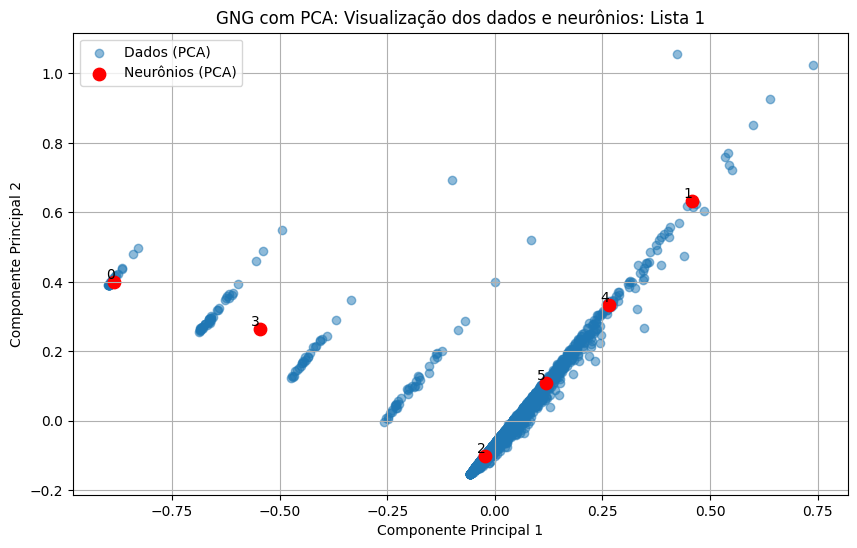

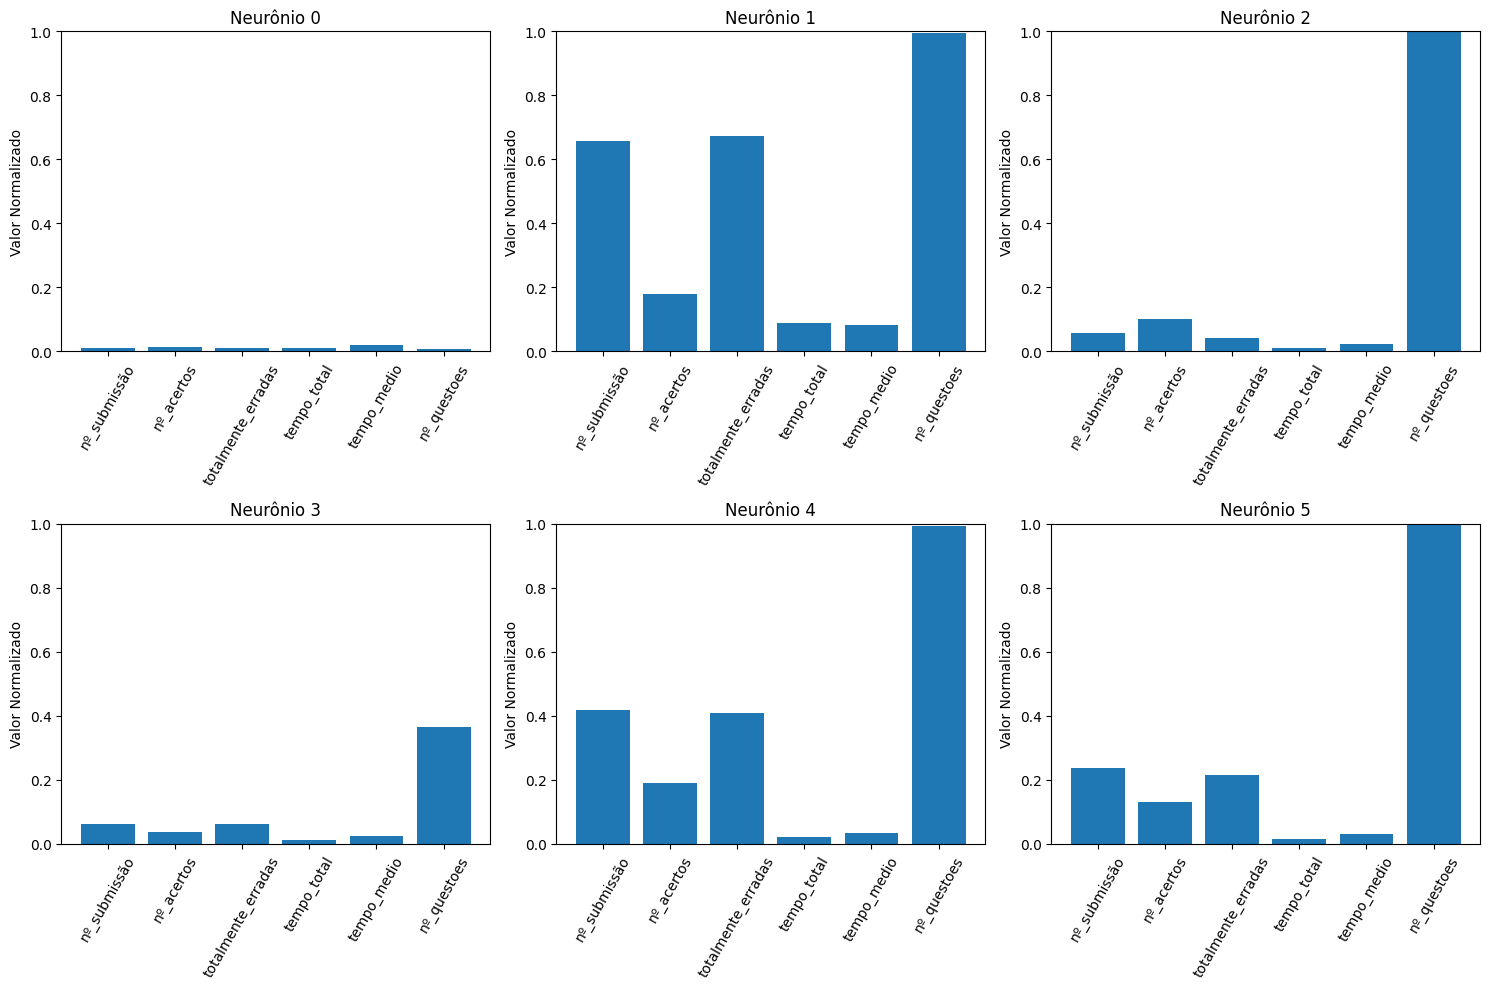

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



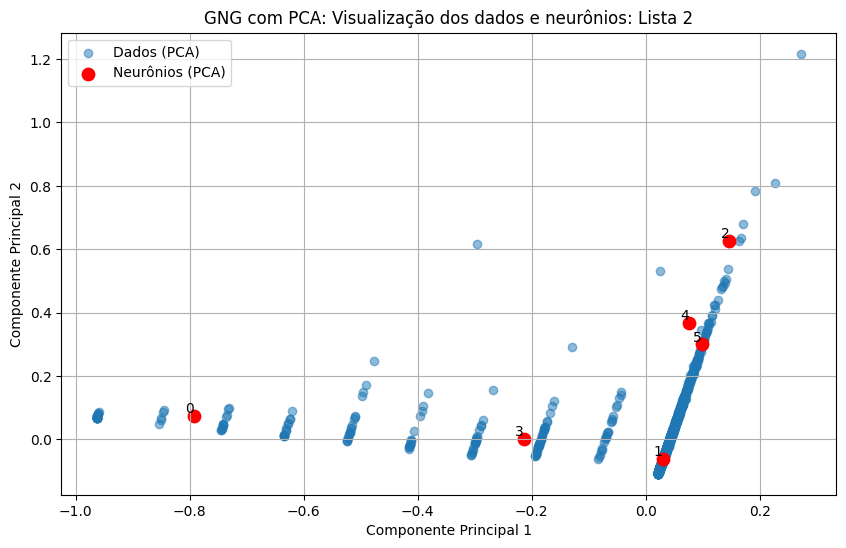

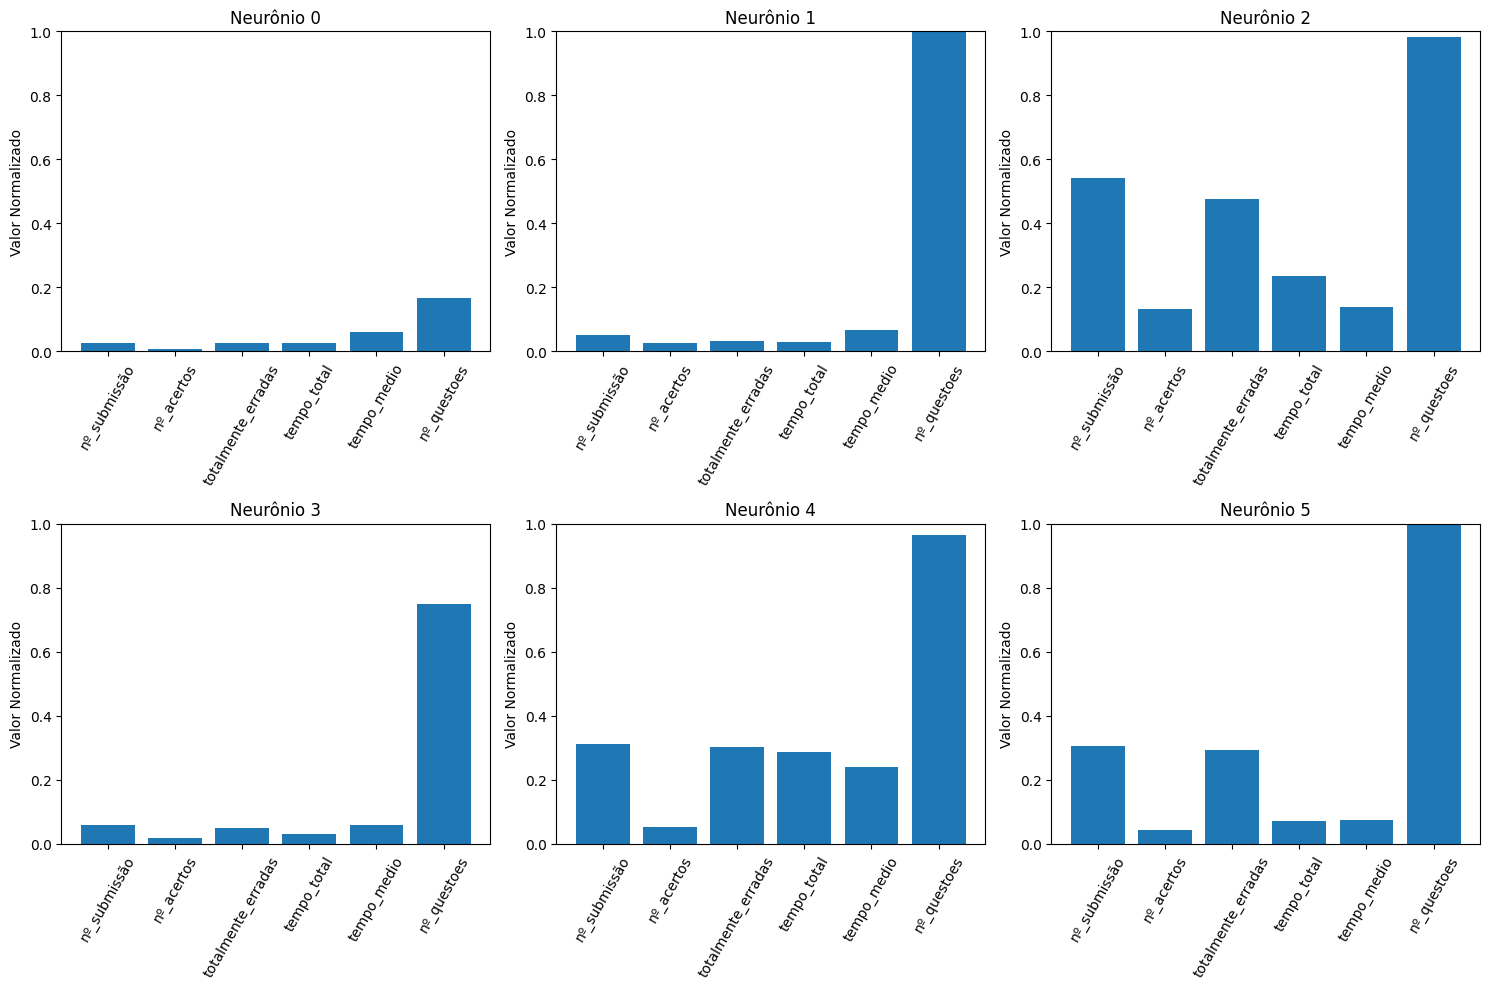

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



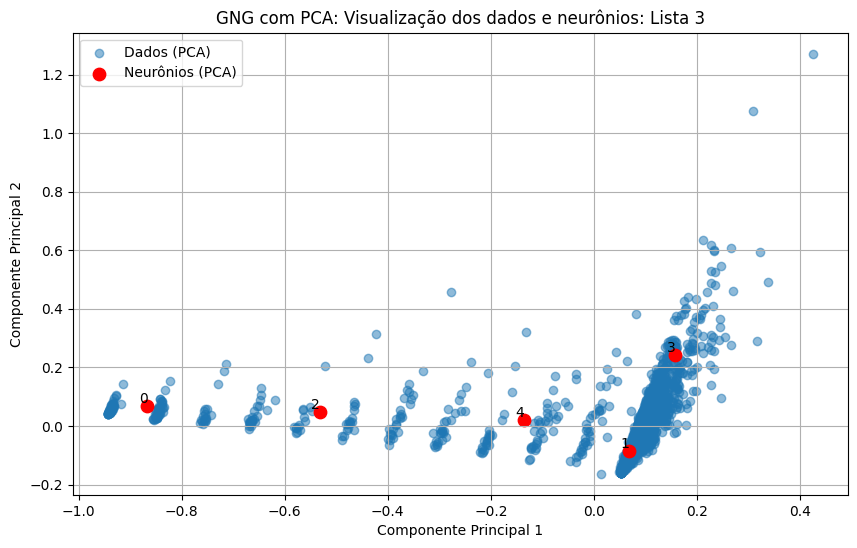

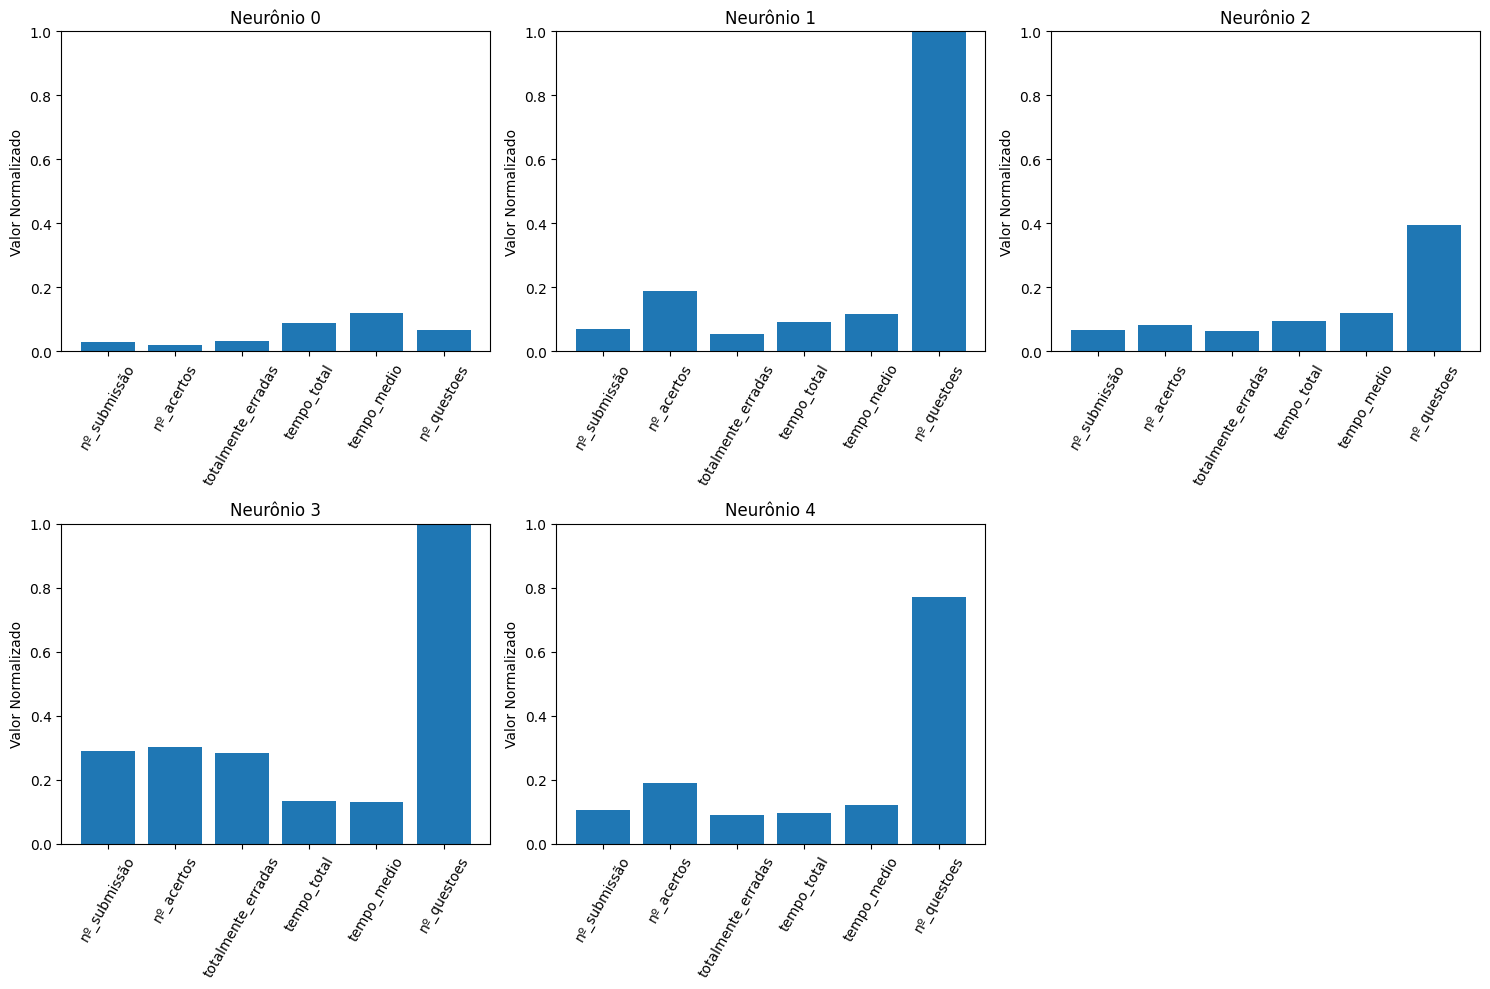

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



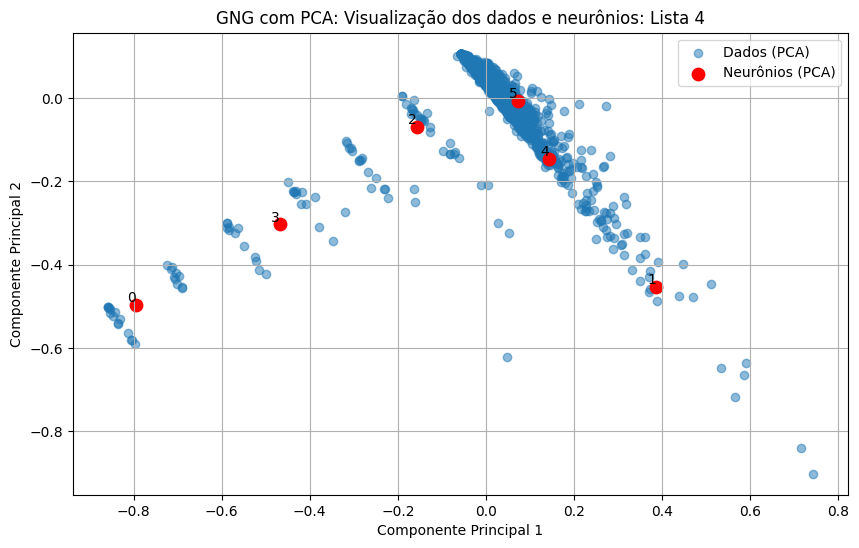

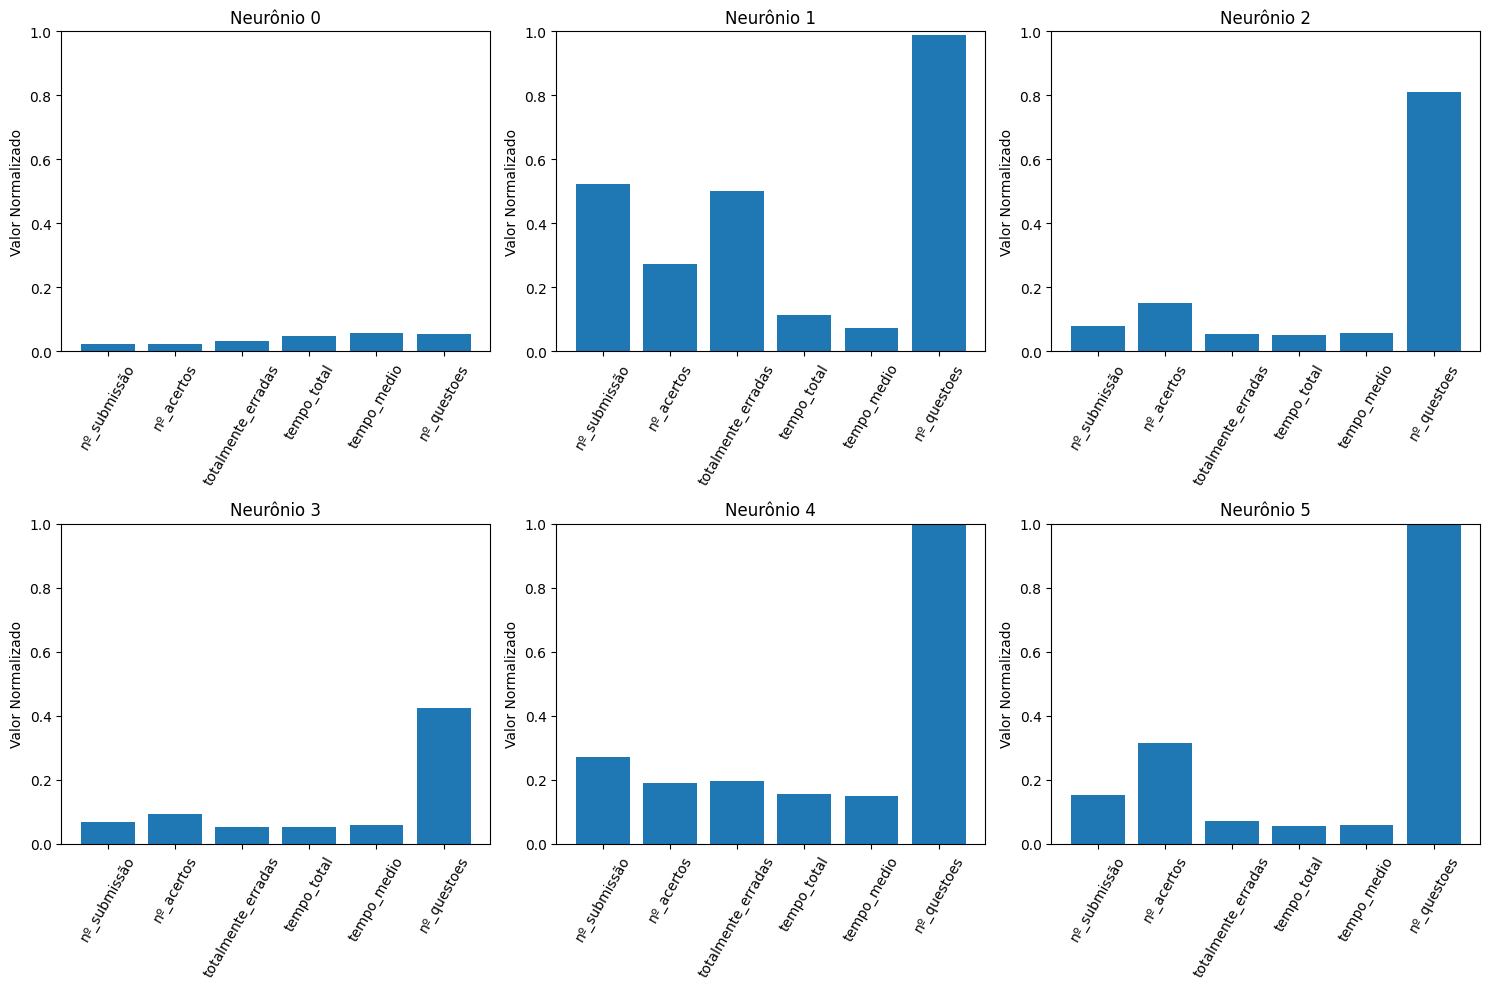

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



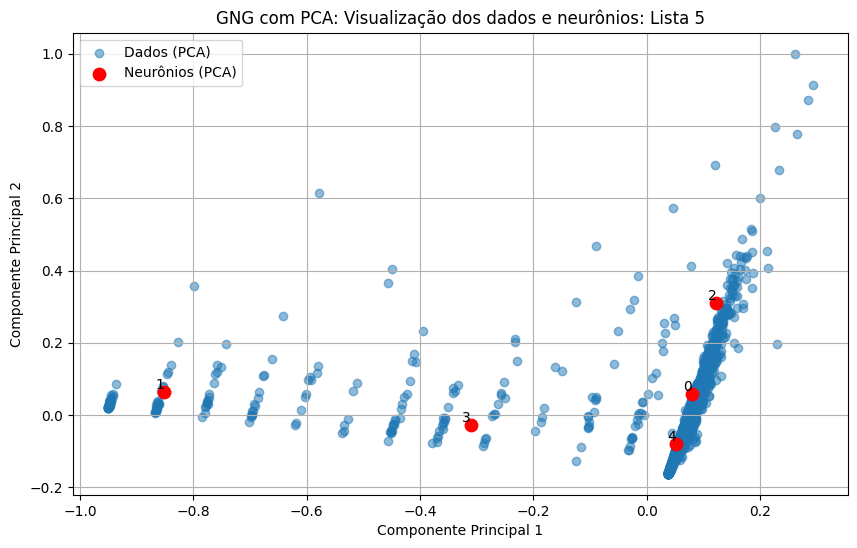

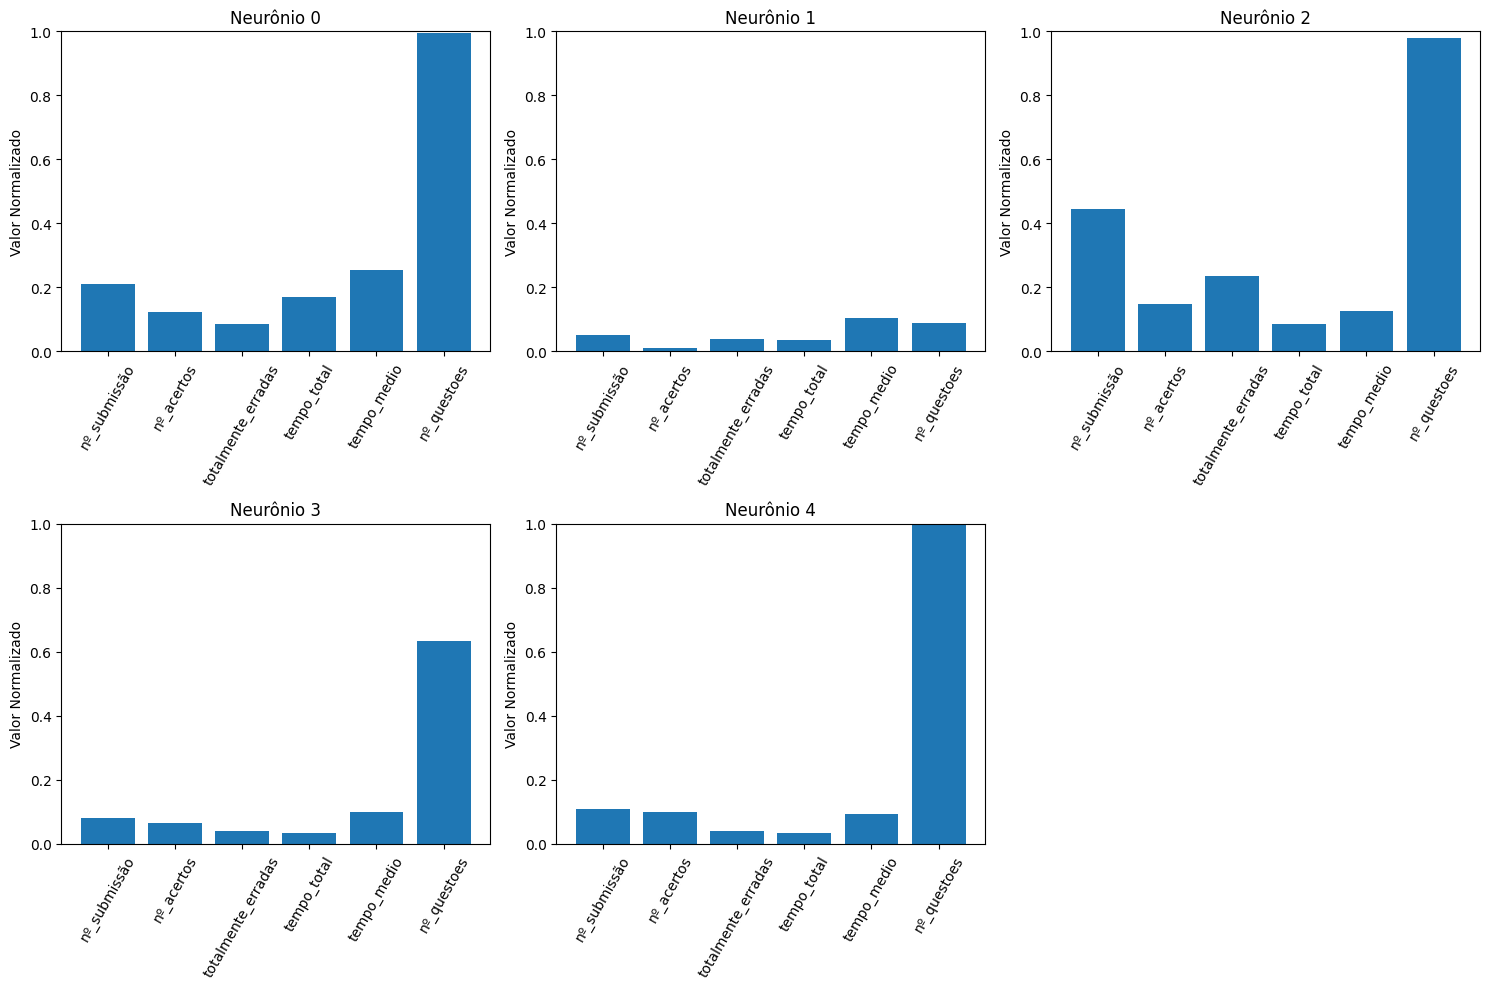

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



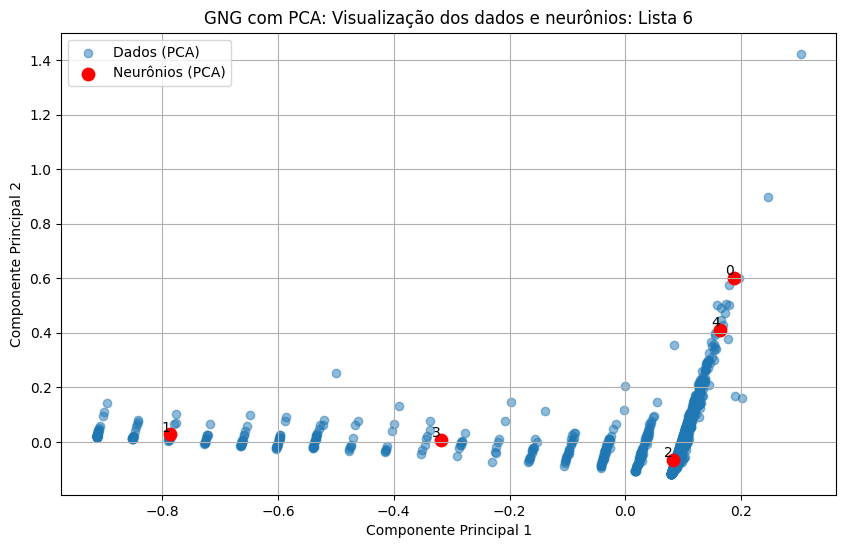

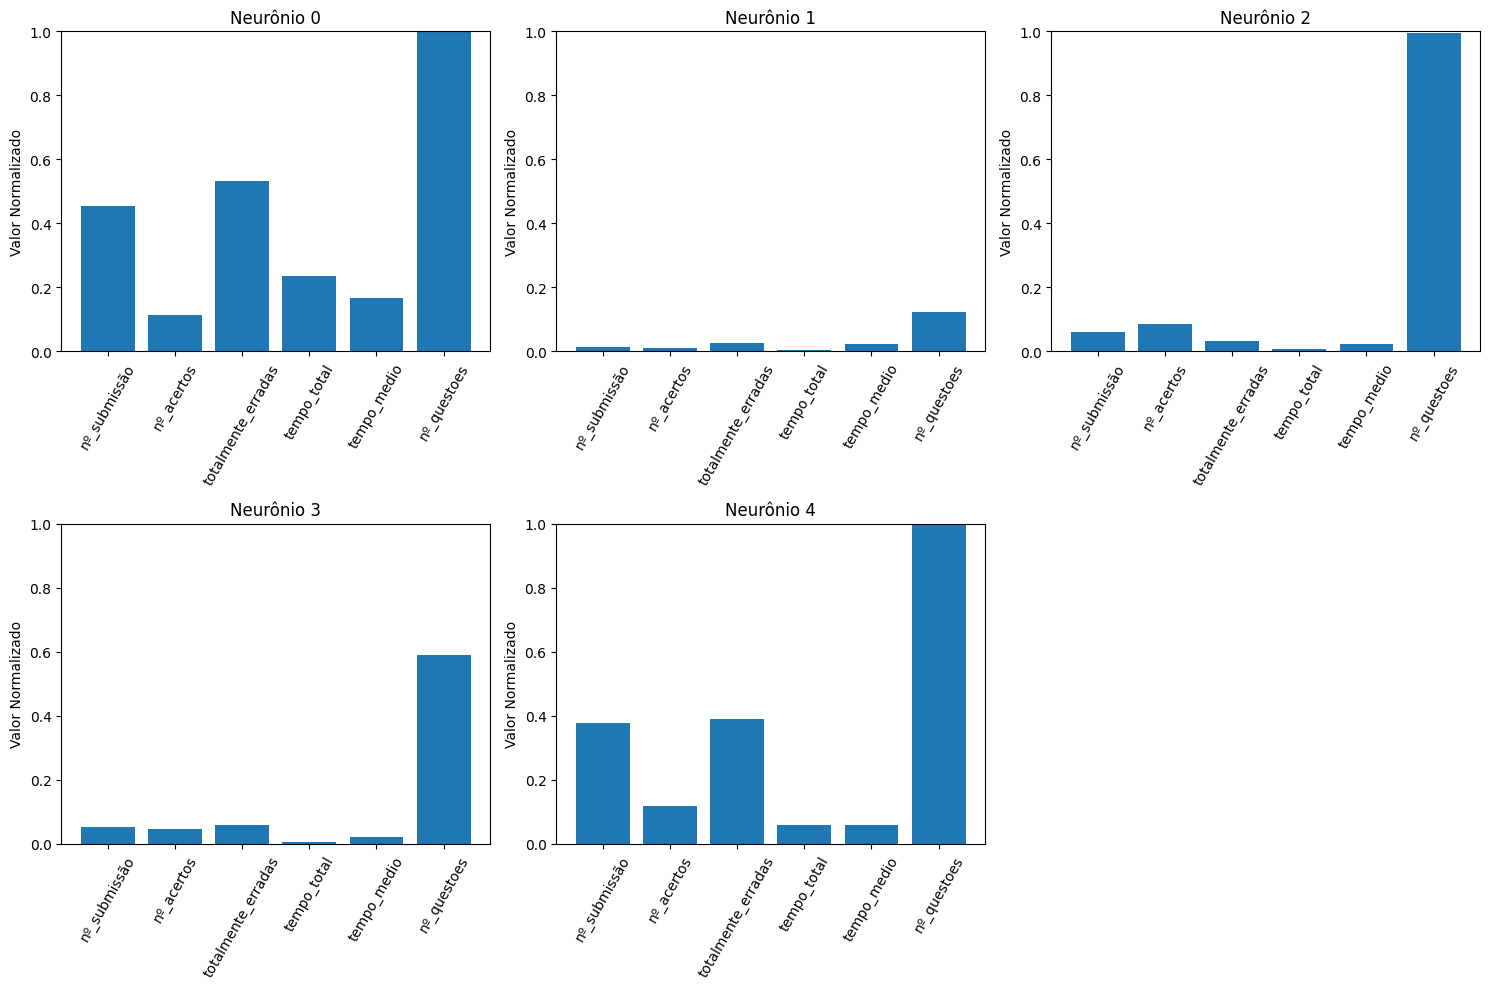

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



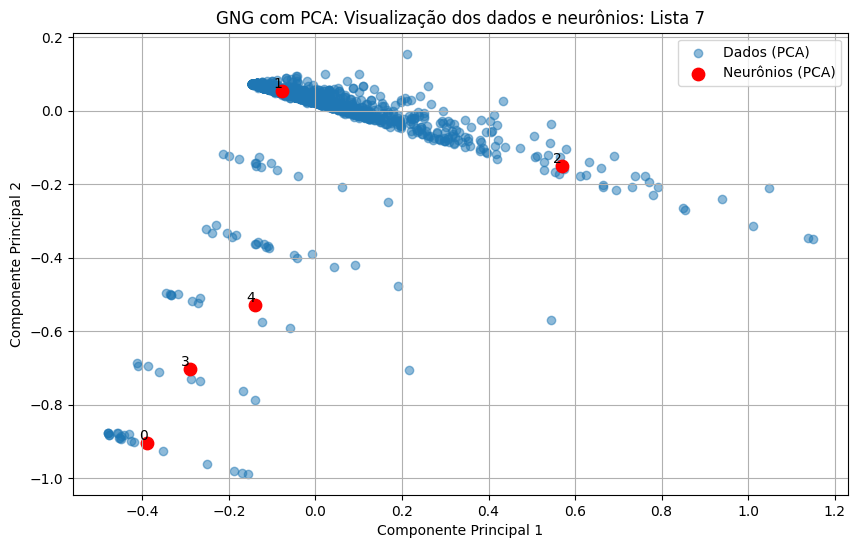

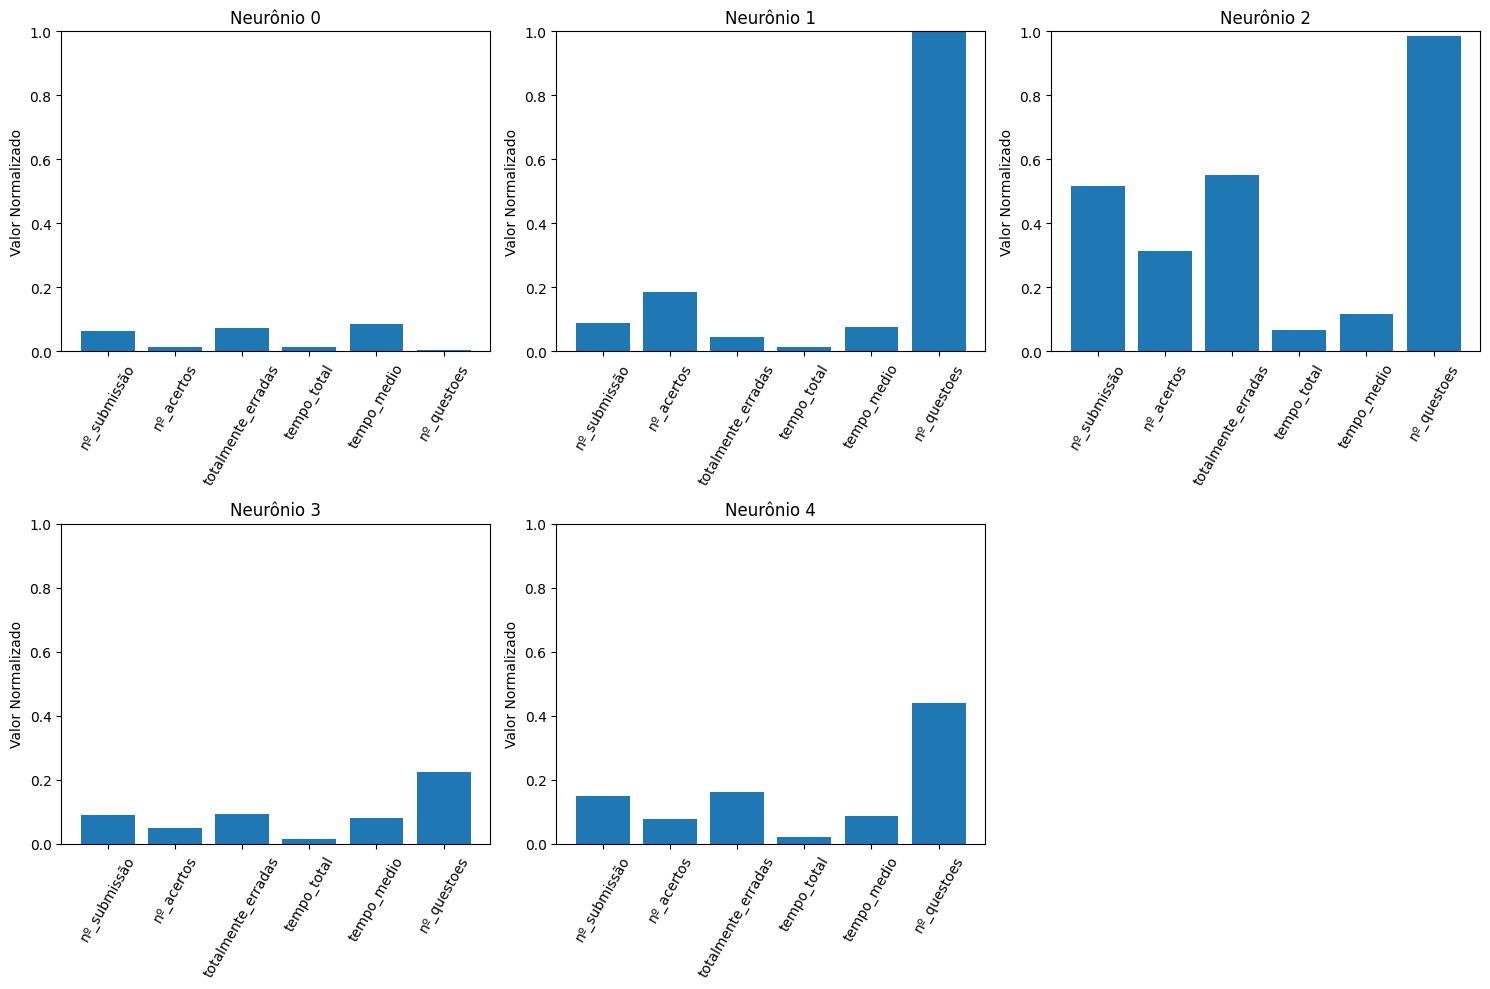

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



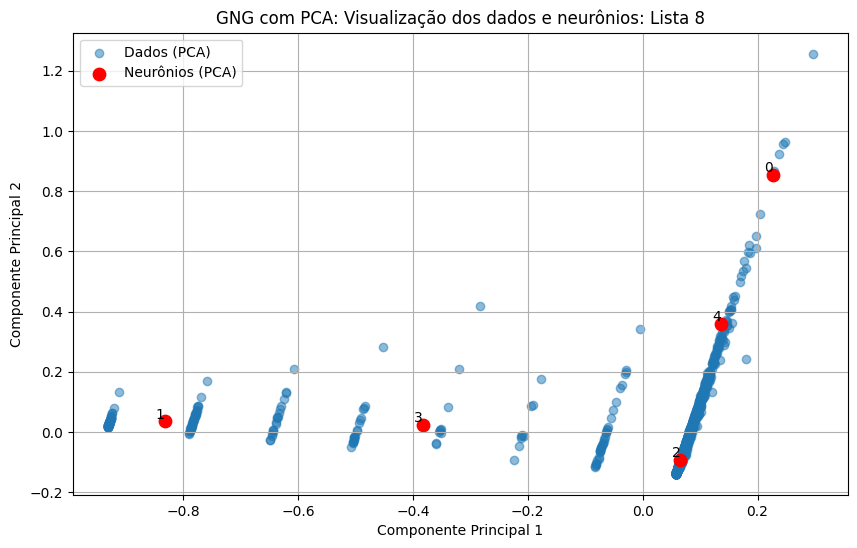

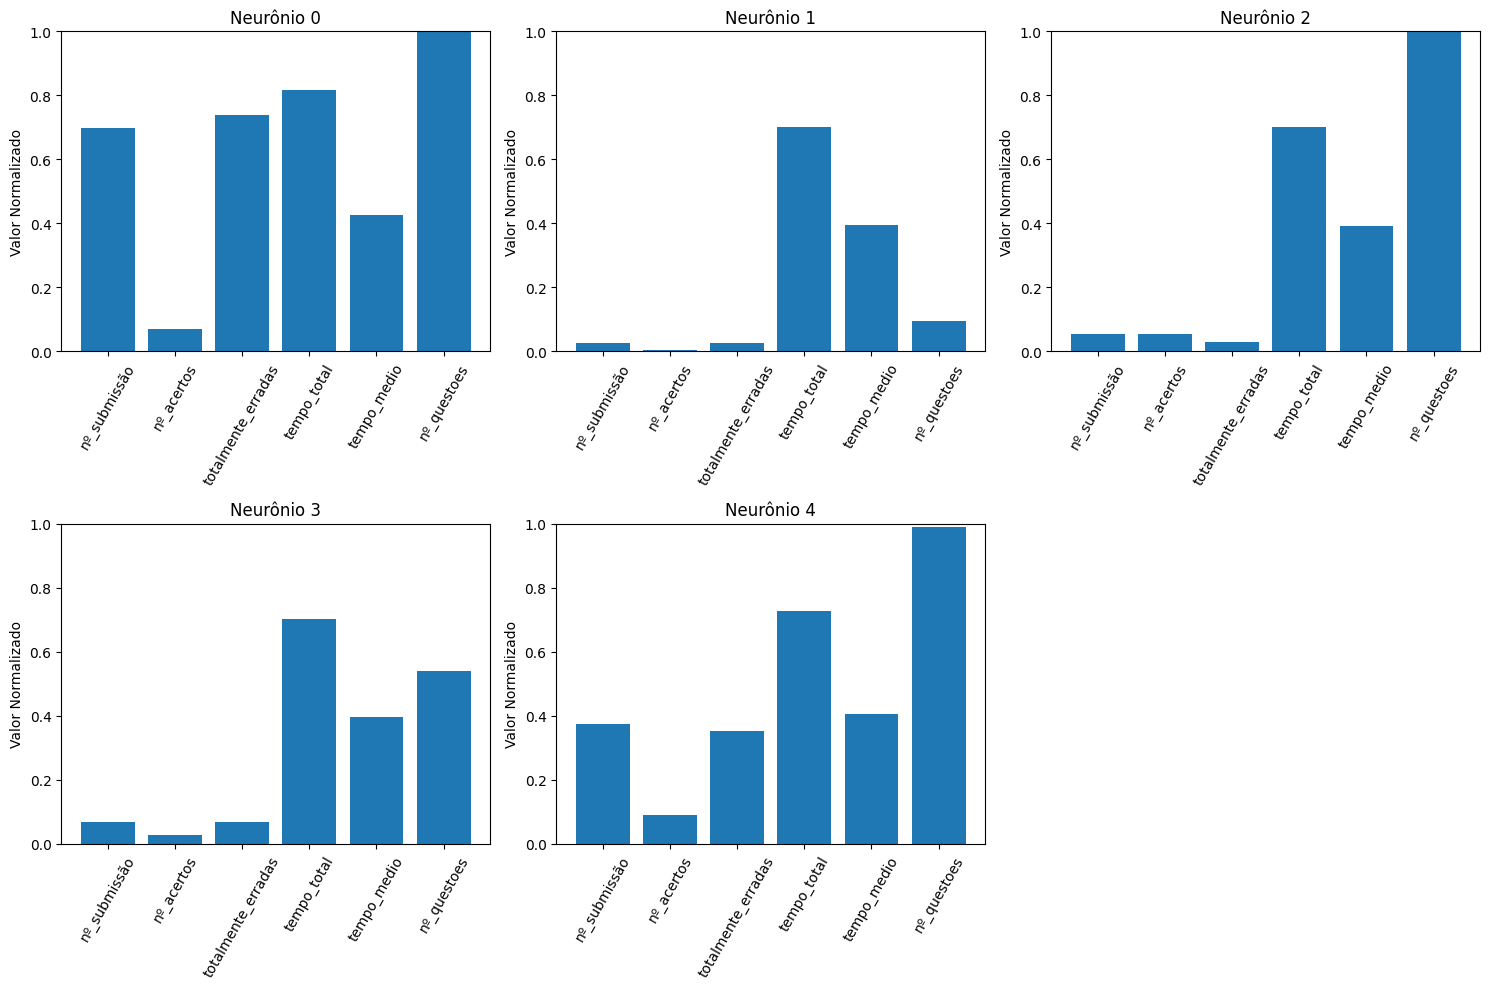

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



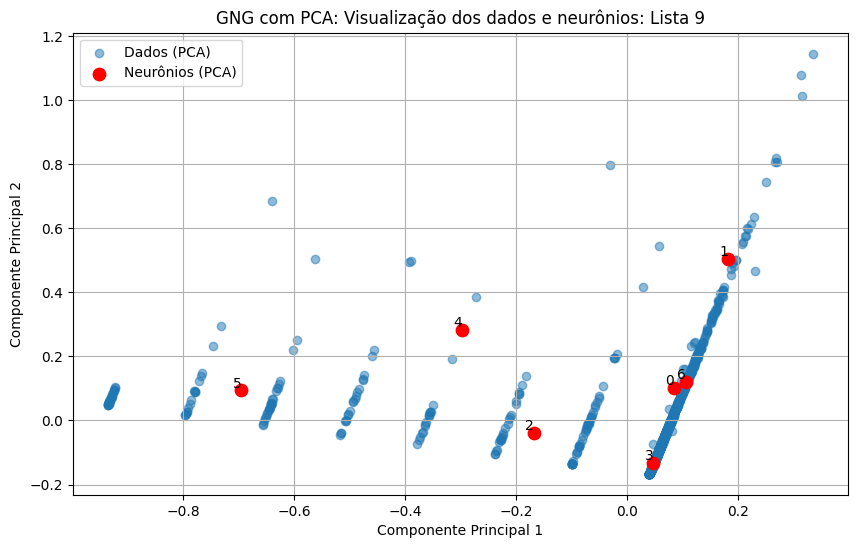

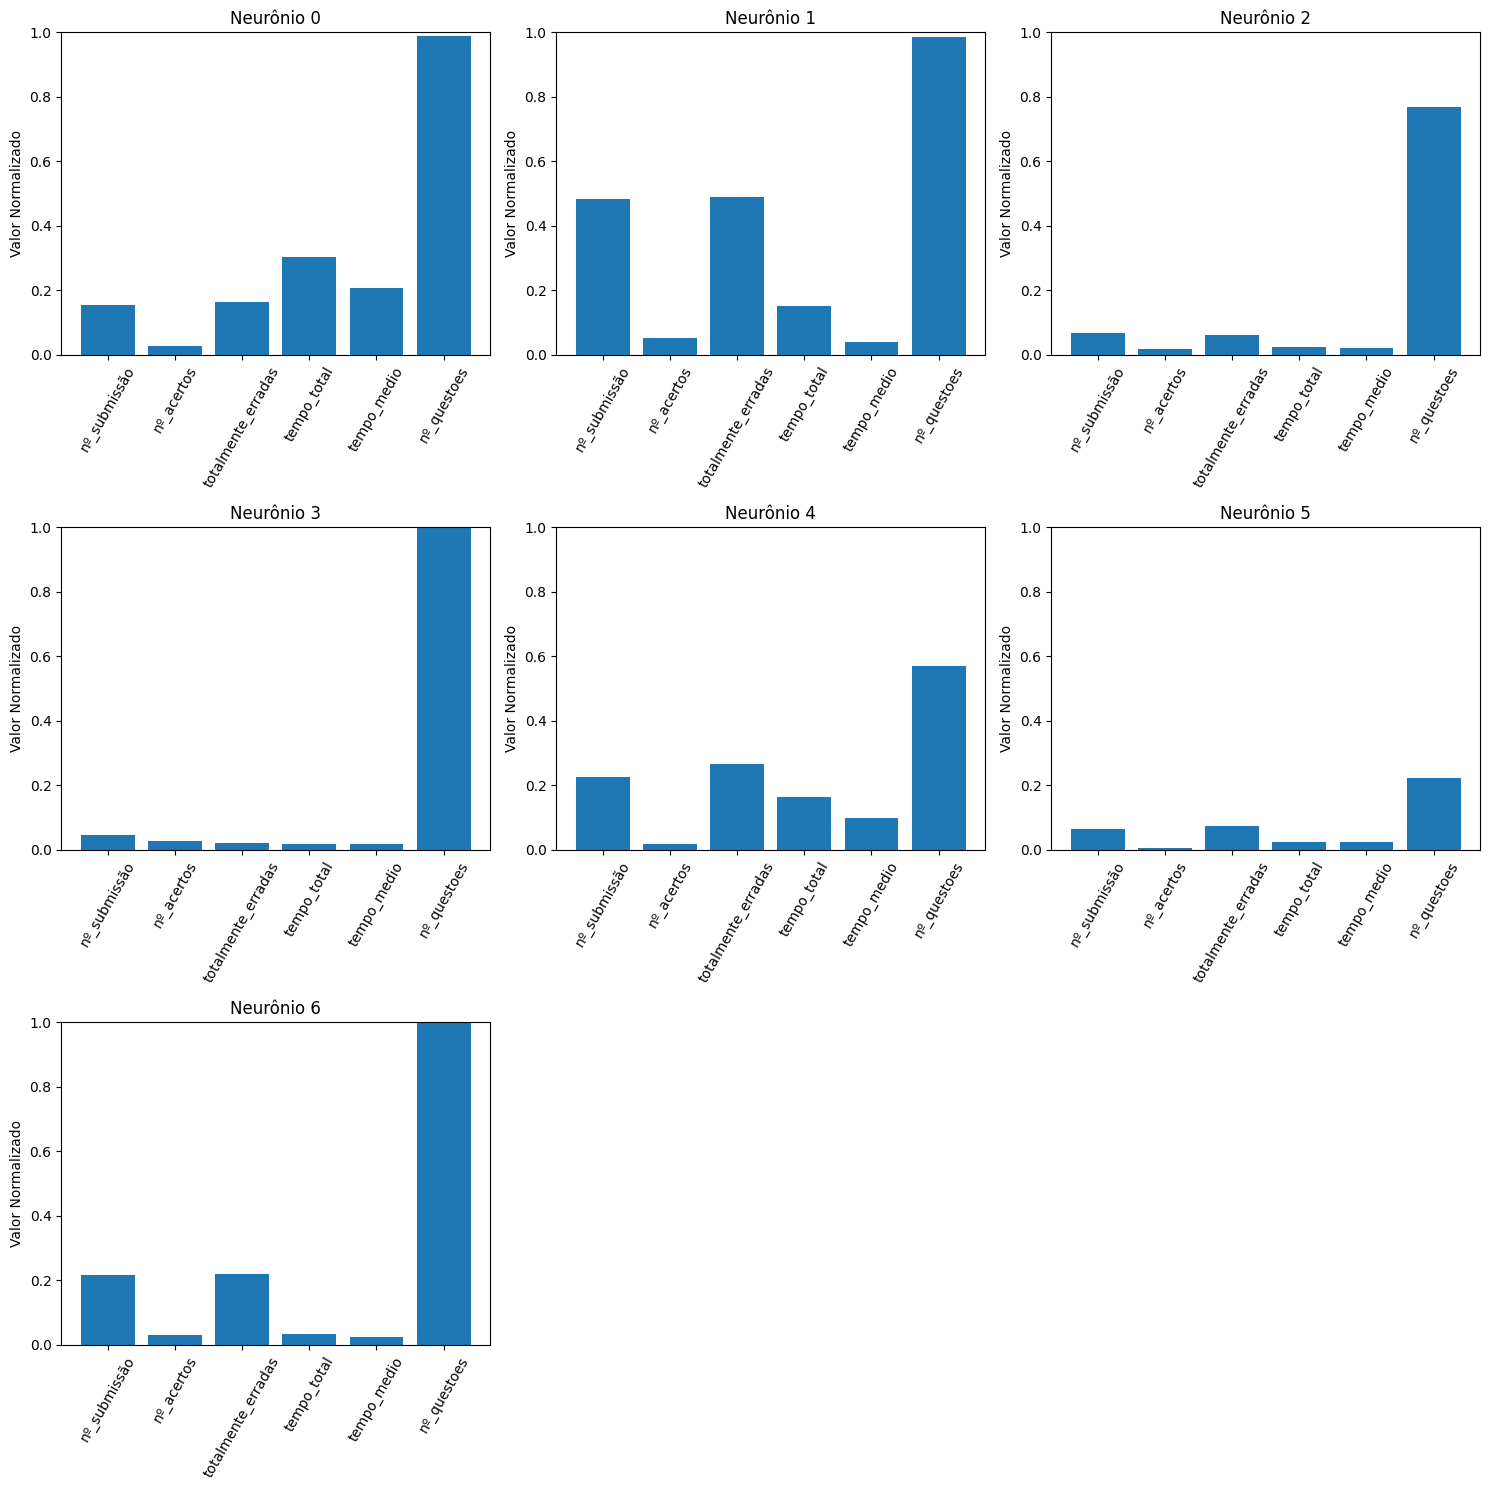

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



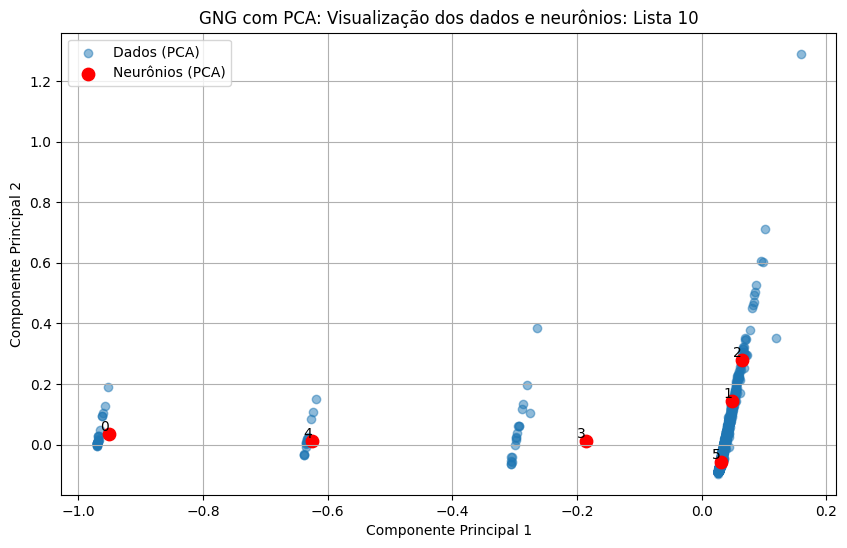

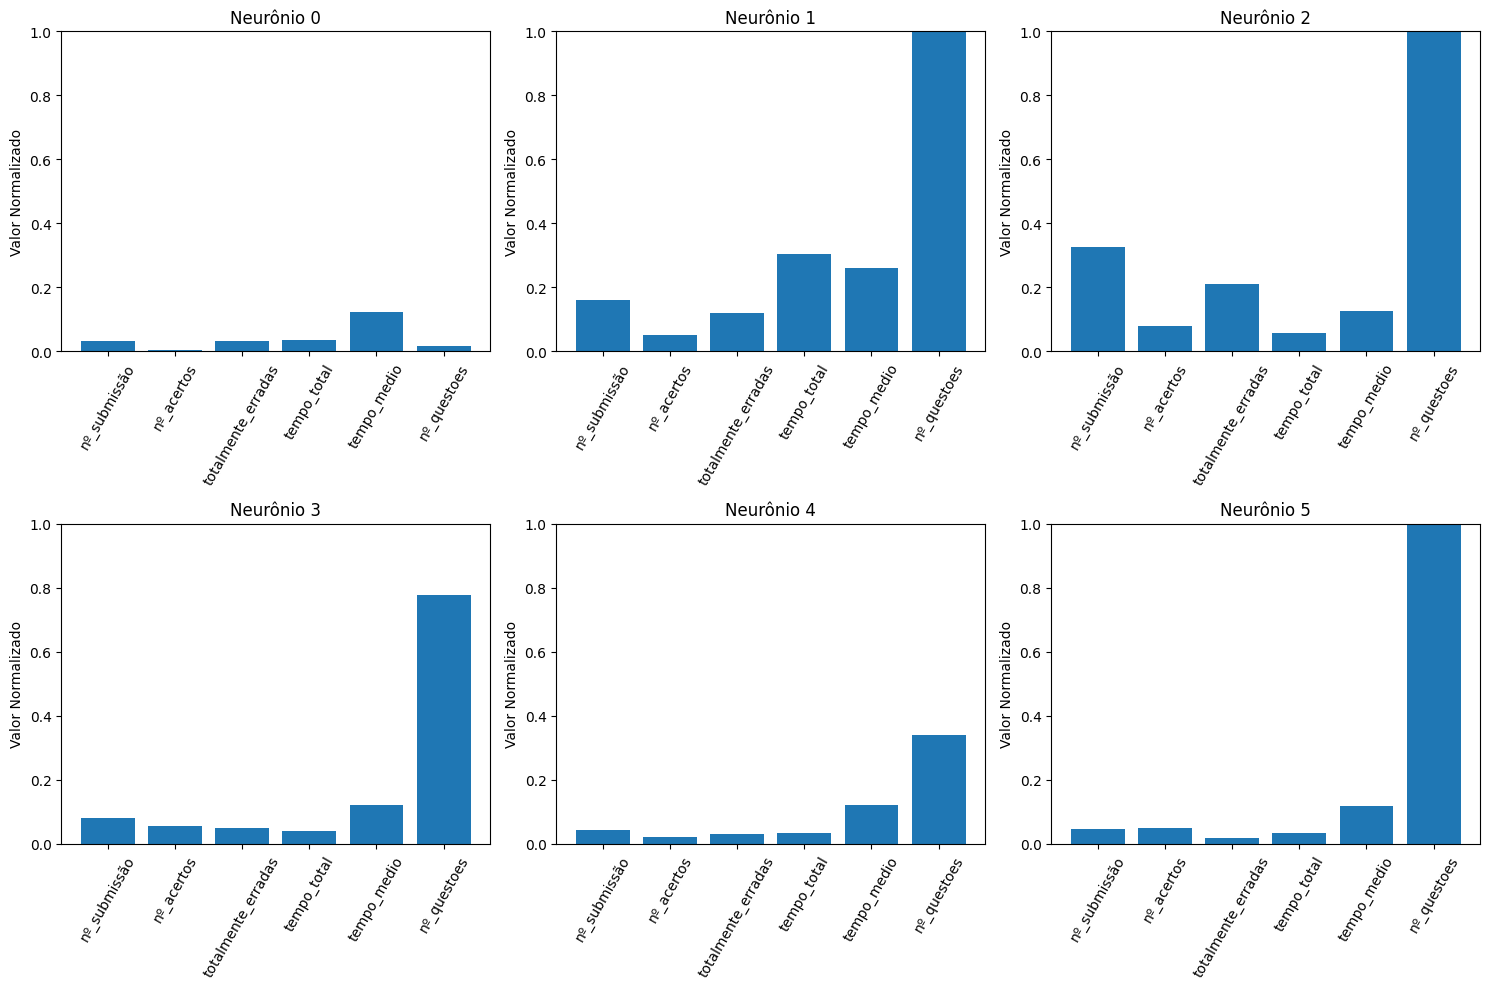

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



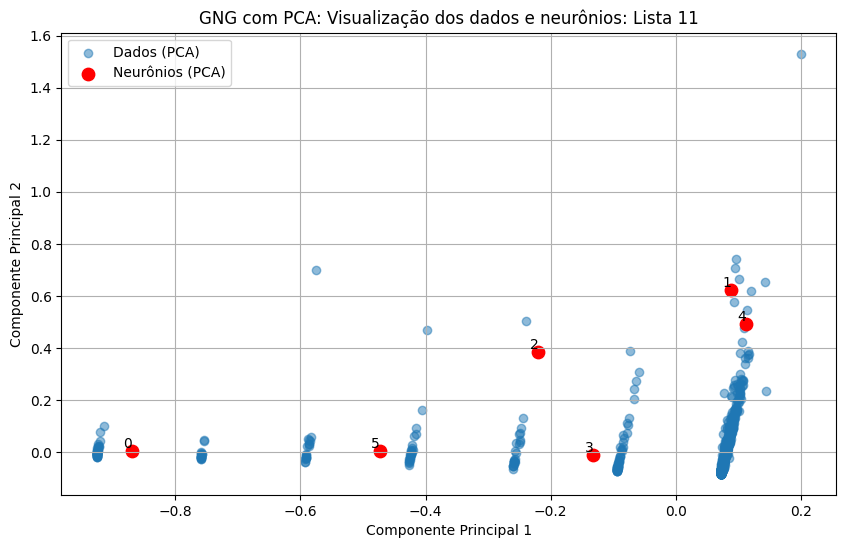

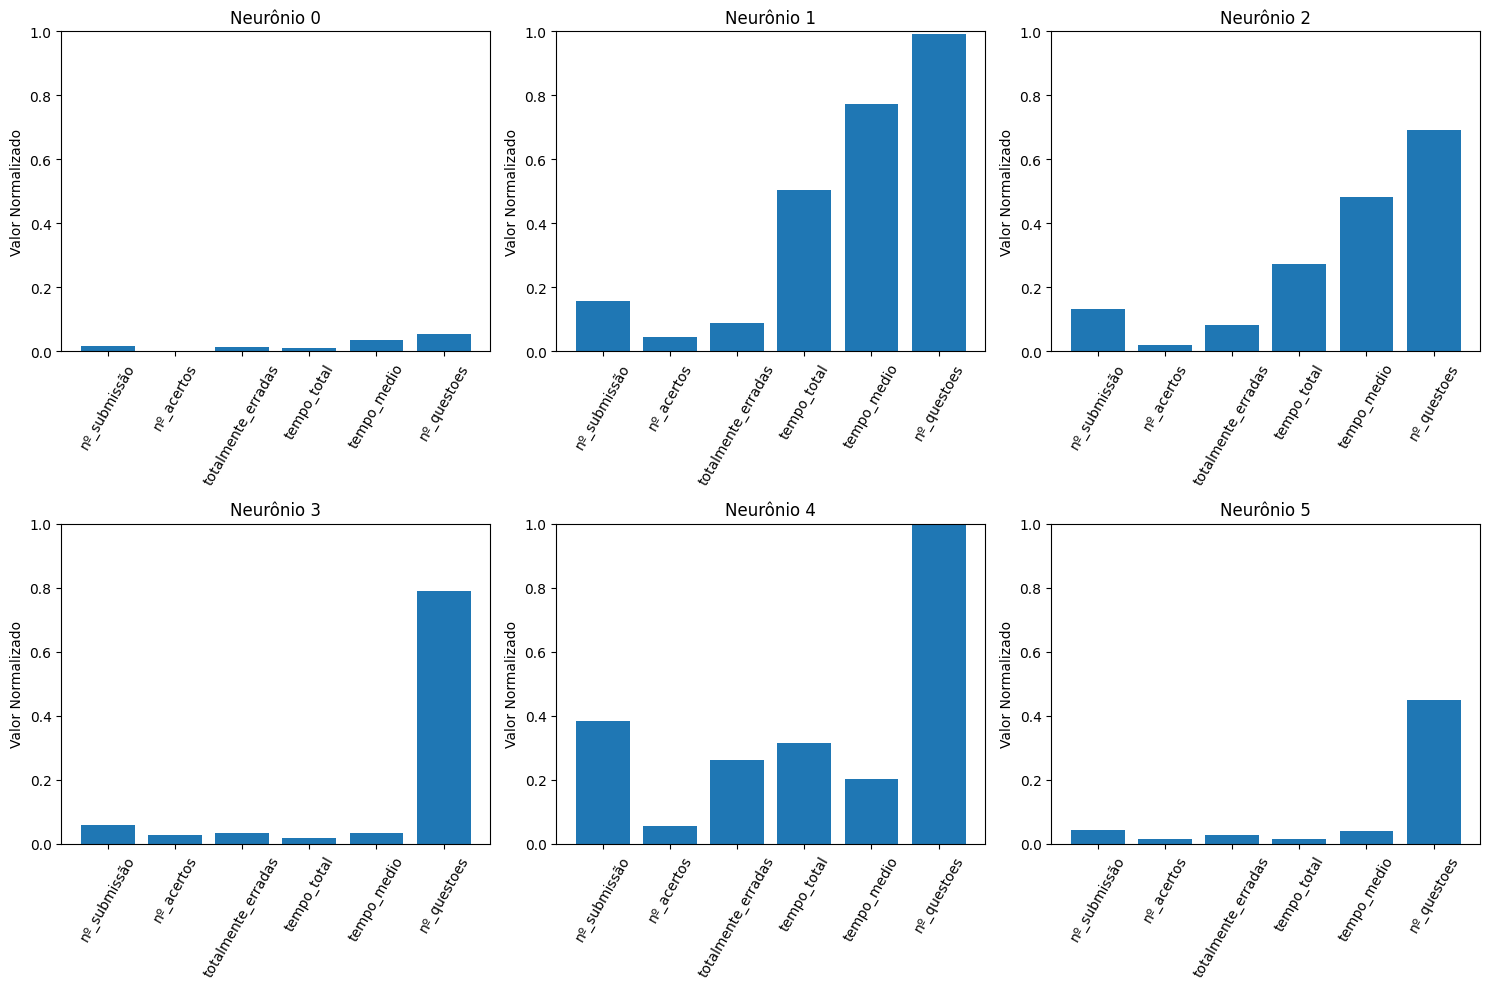

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



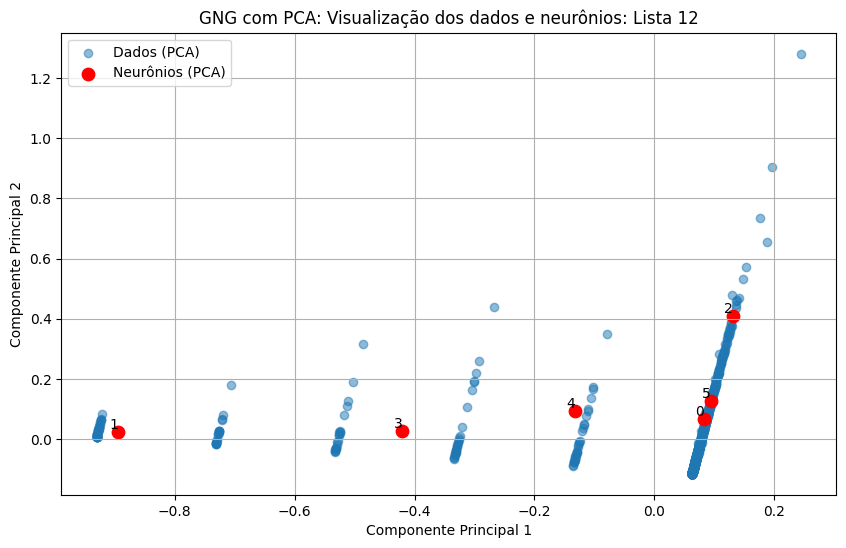

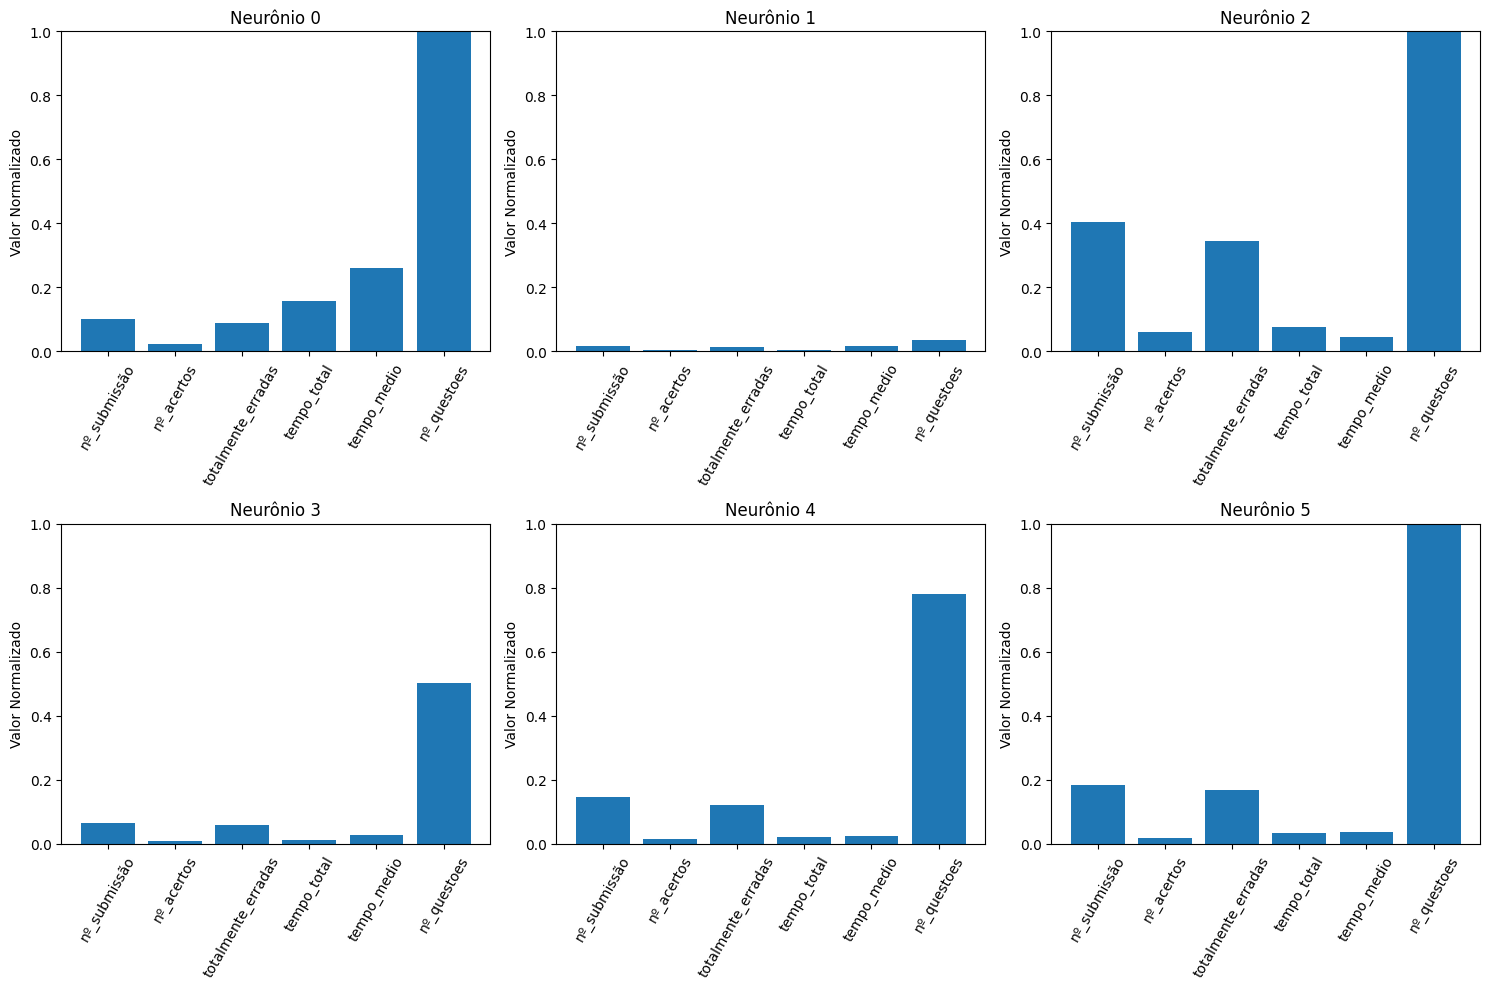

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



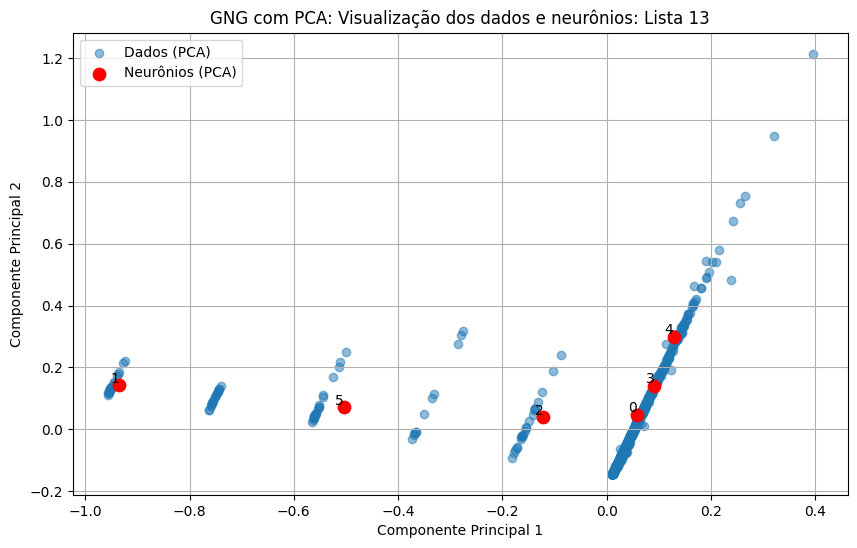

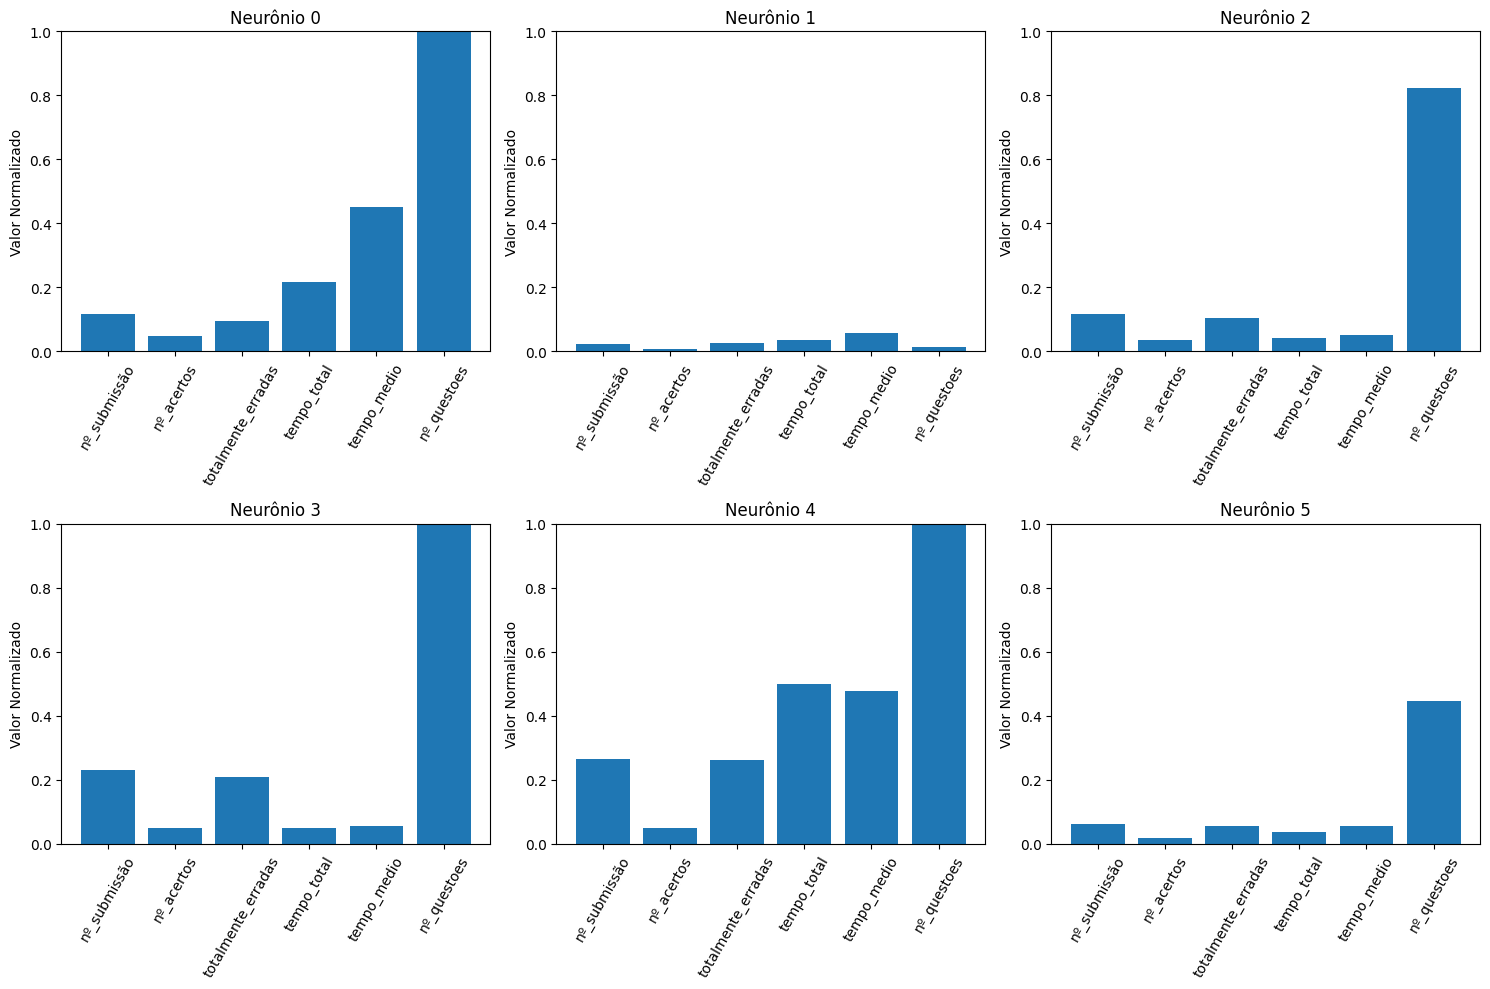

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



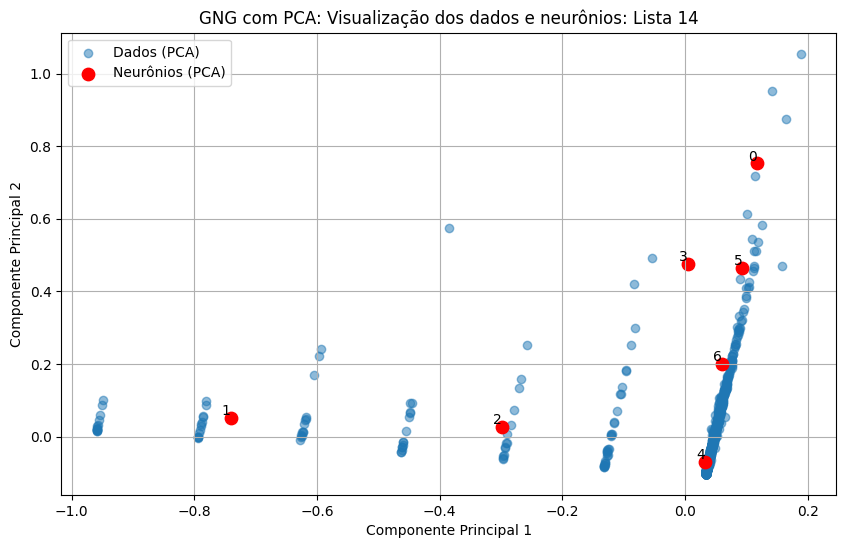

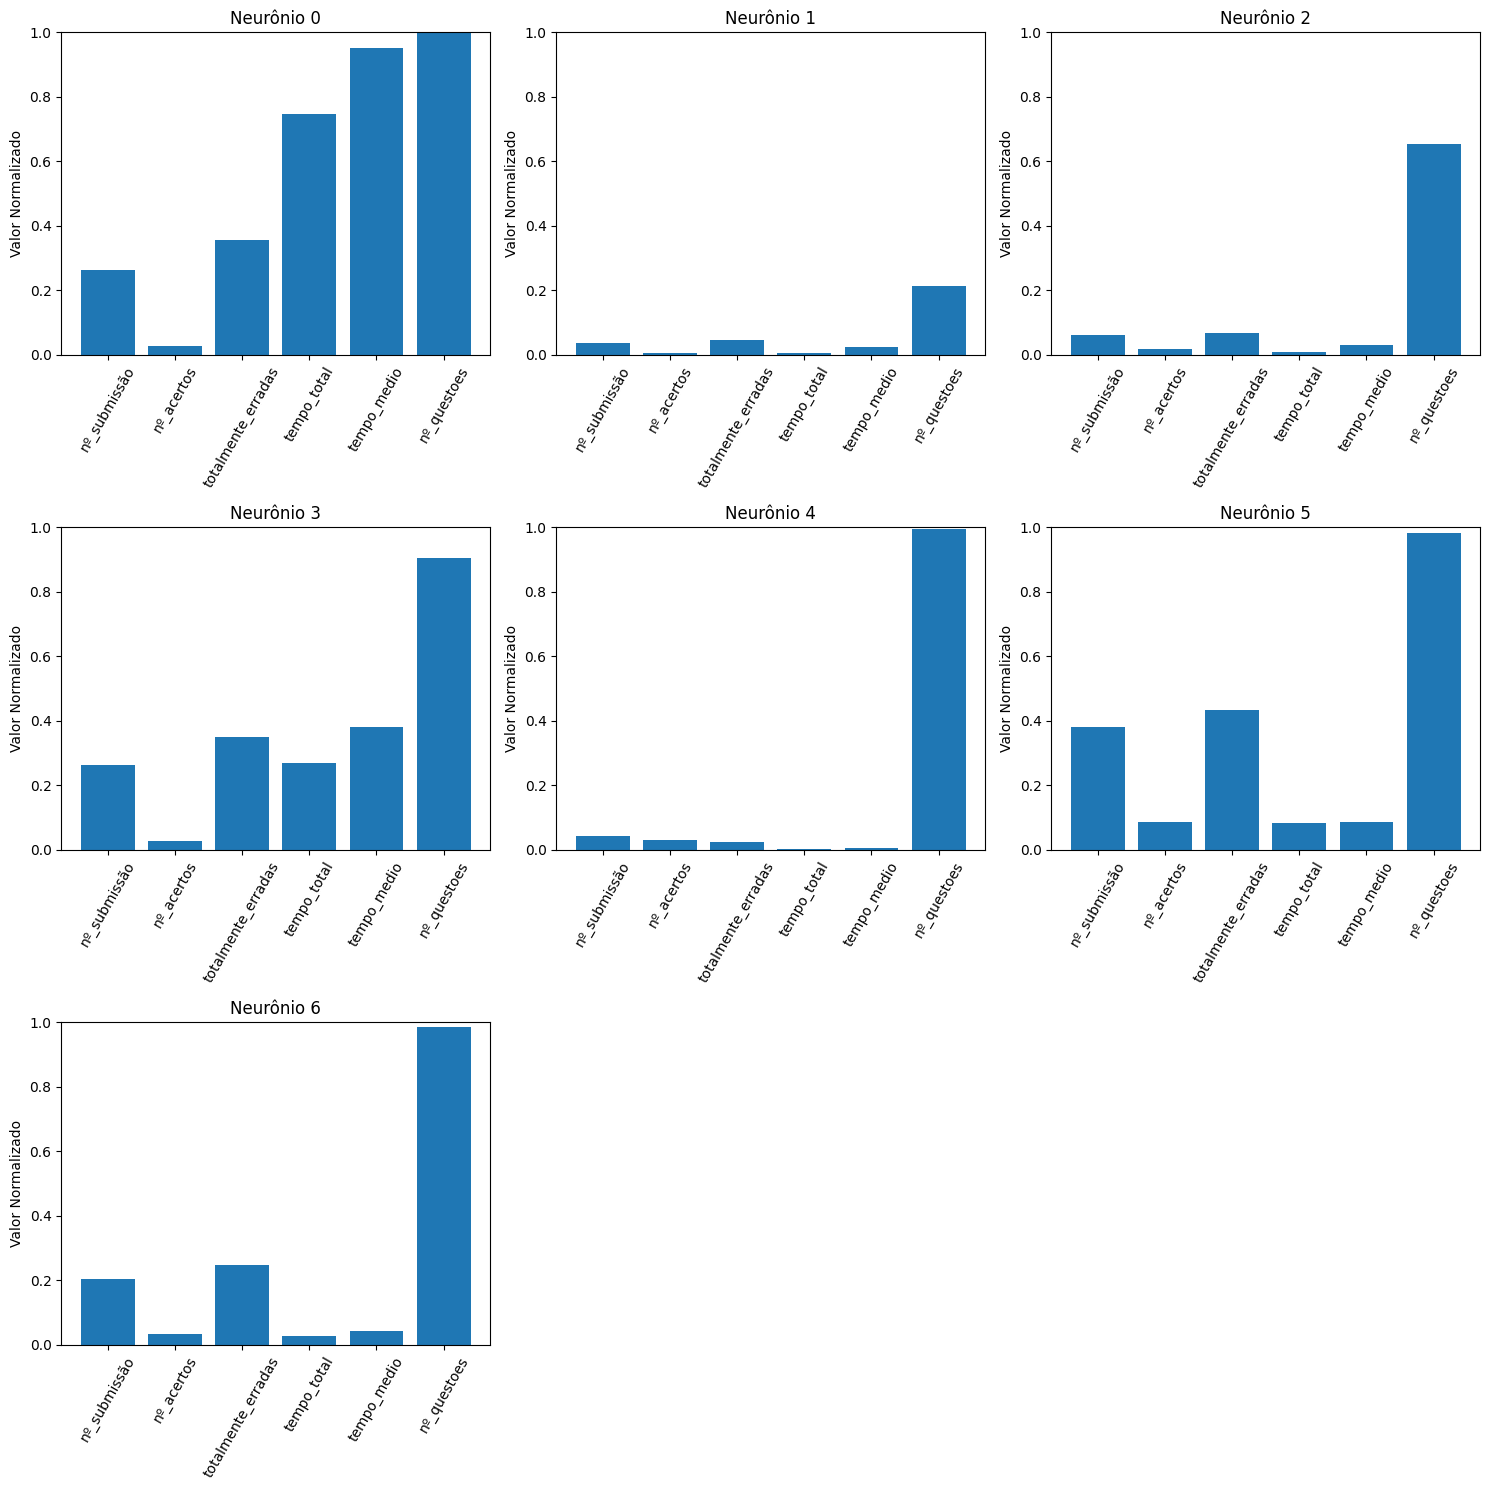

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



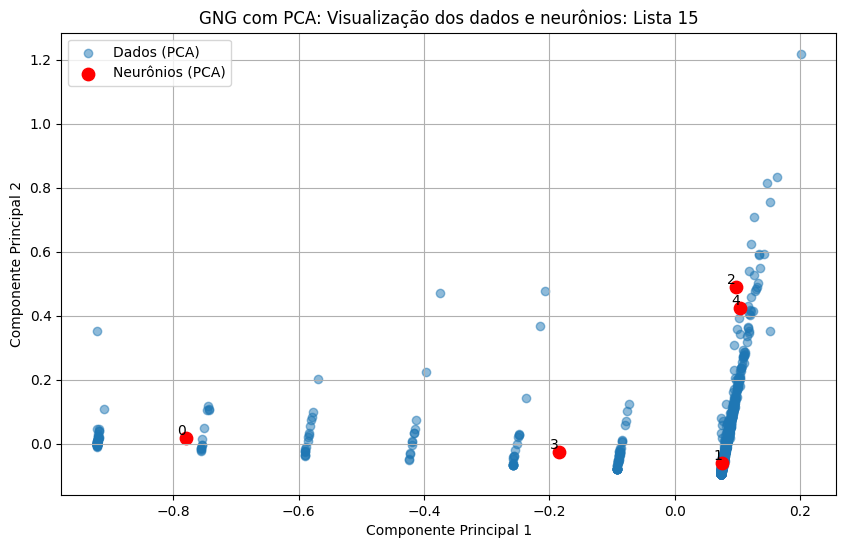

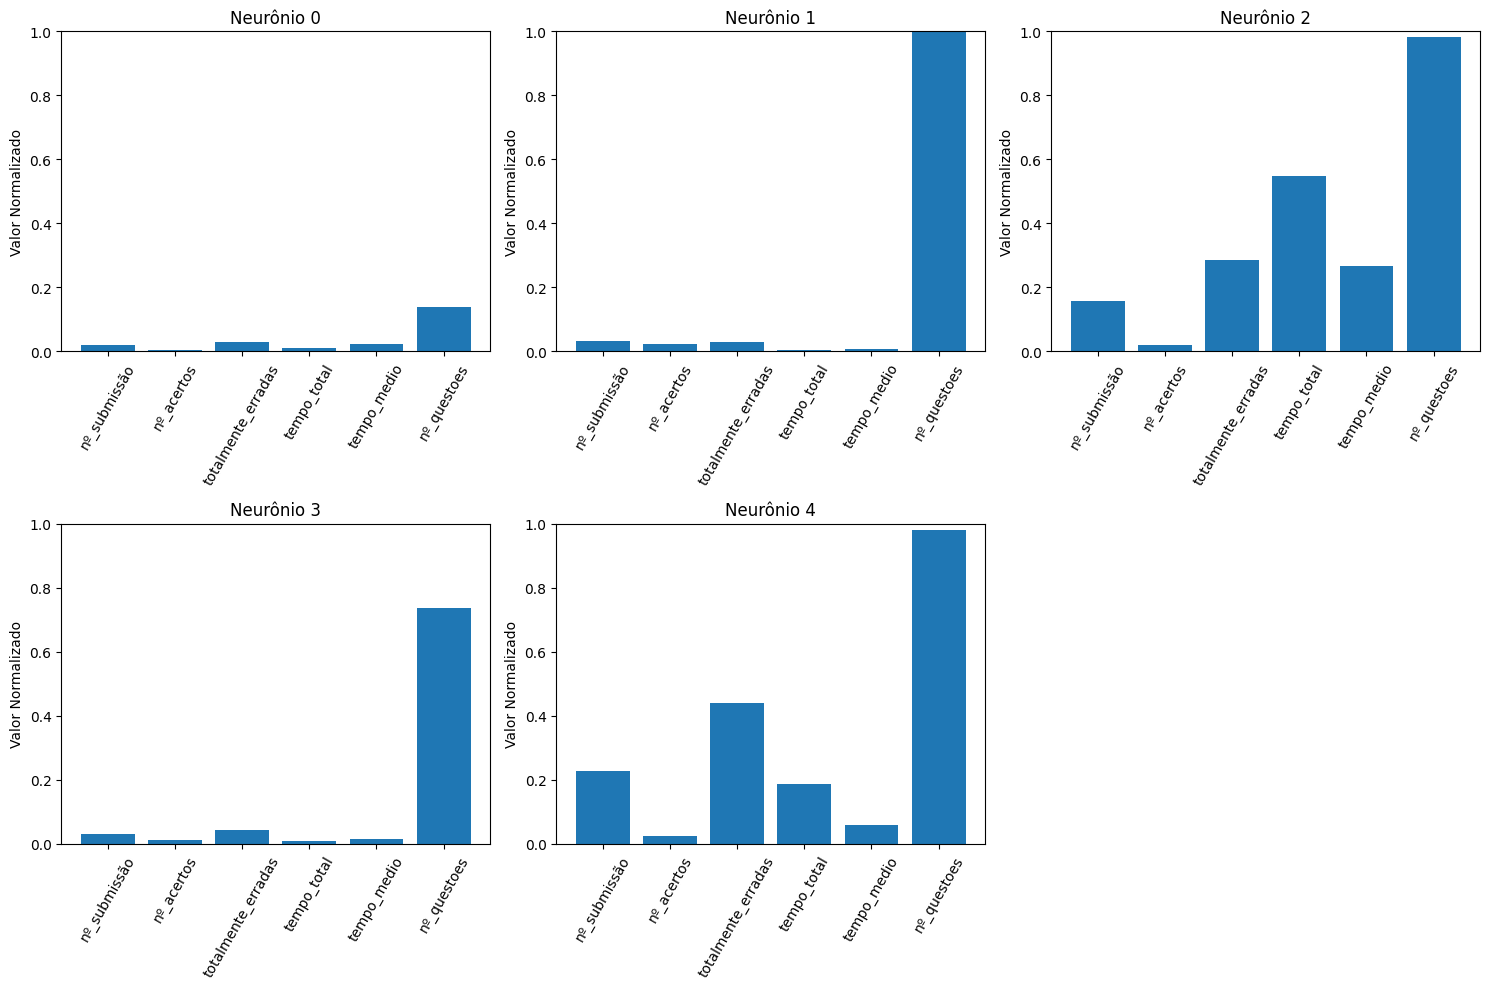

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



In [ ]:
for i in range(len(listas_processadas)):
  plot_gng(listas_processadas[i][0],listas_processadas[i][1],i+1)

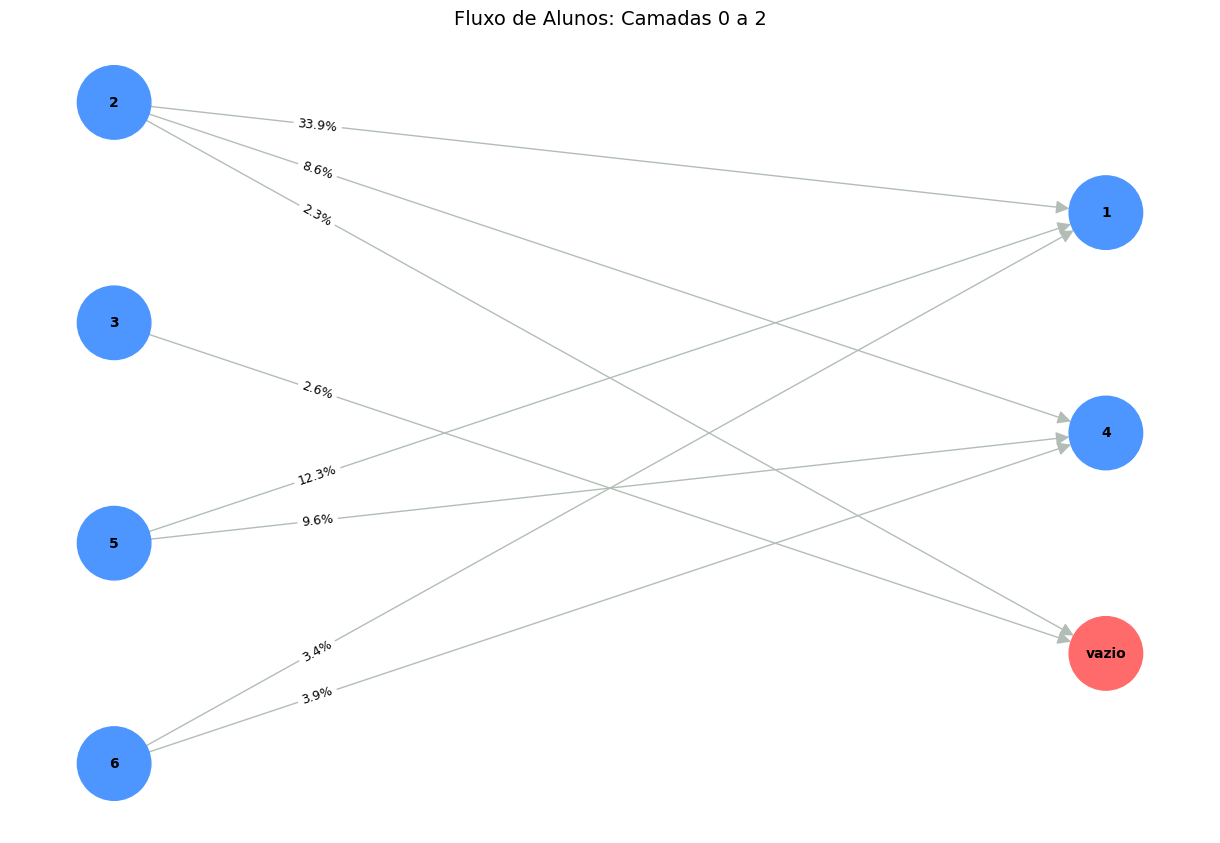

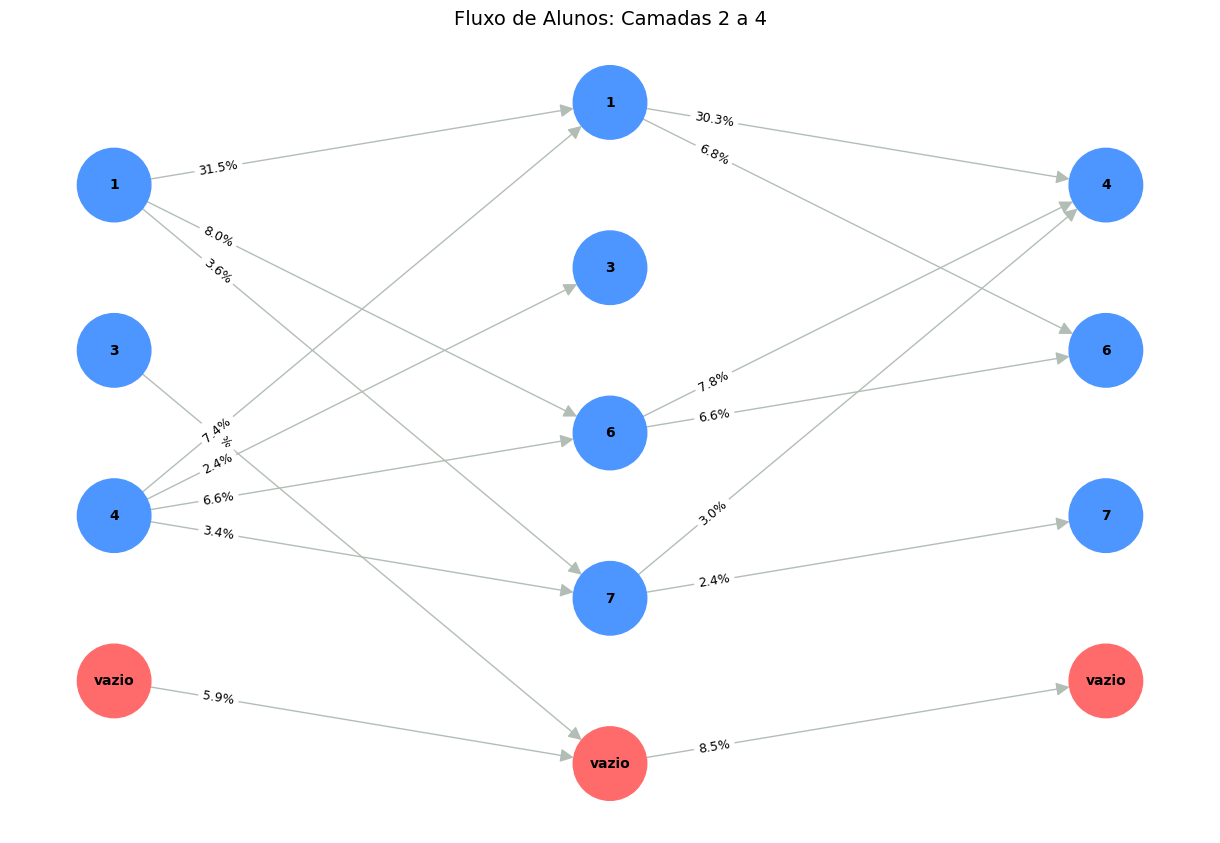

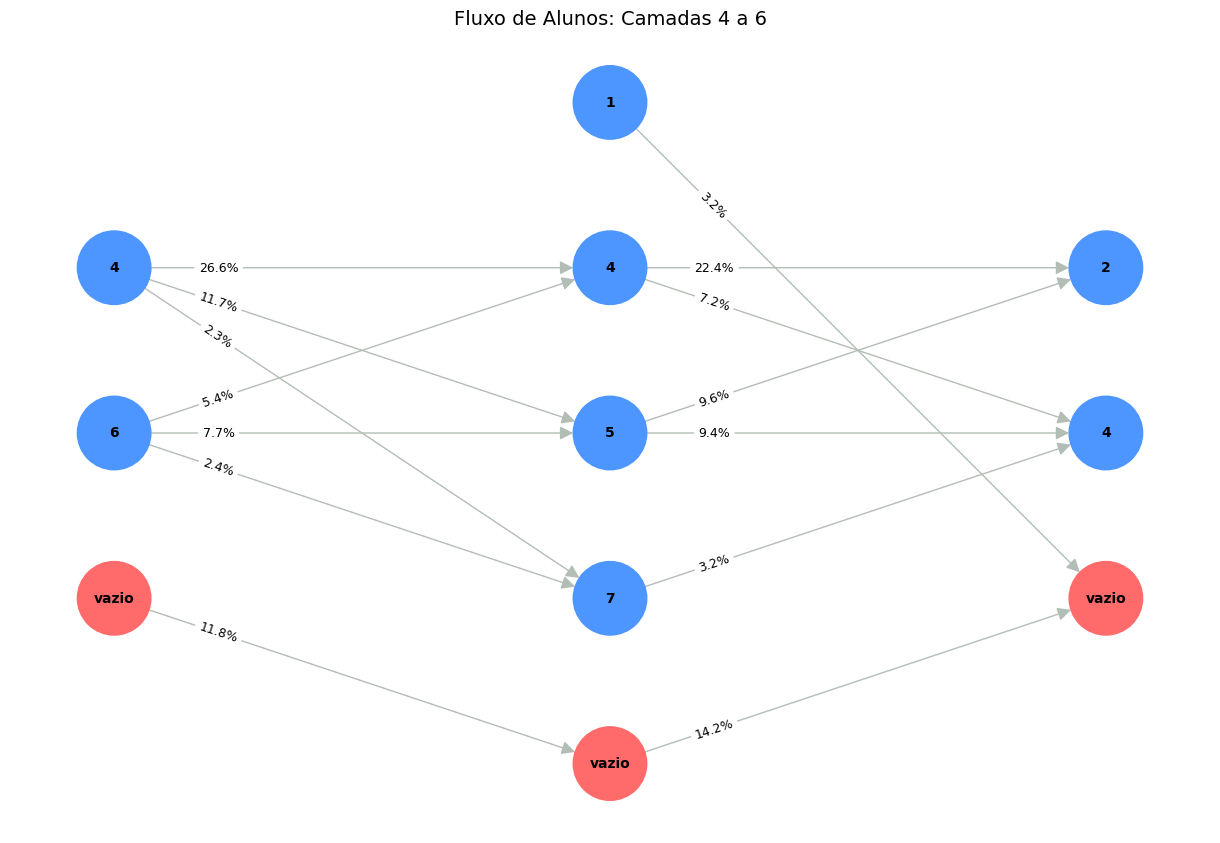

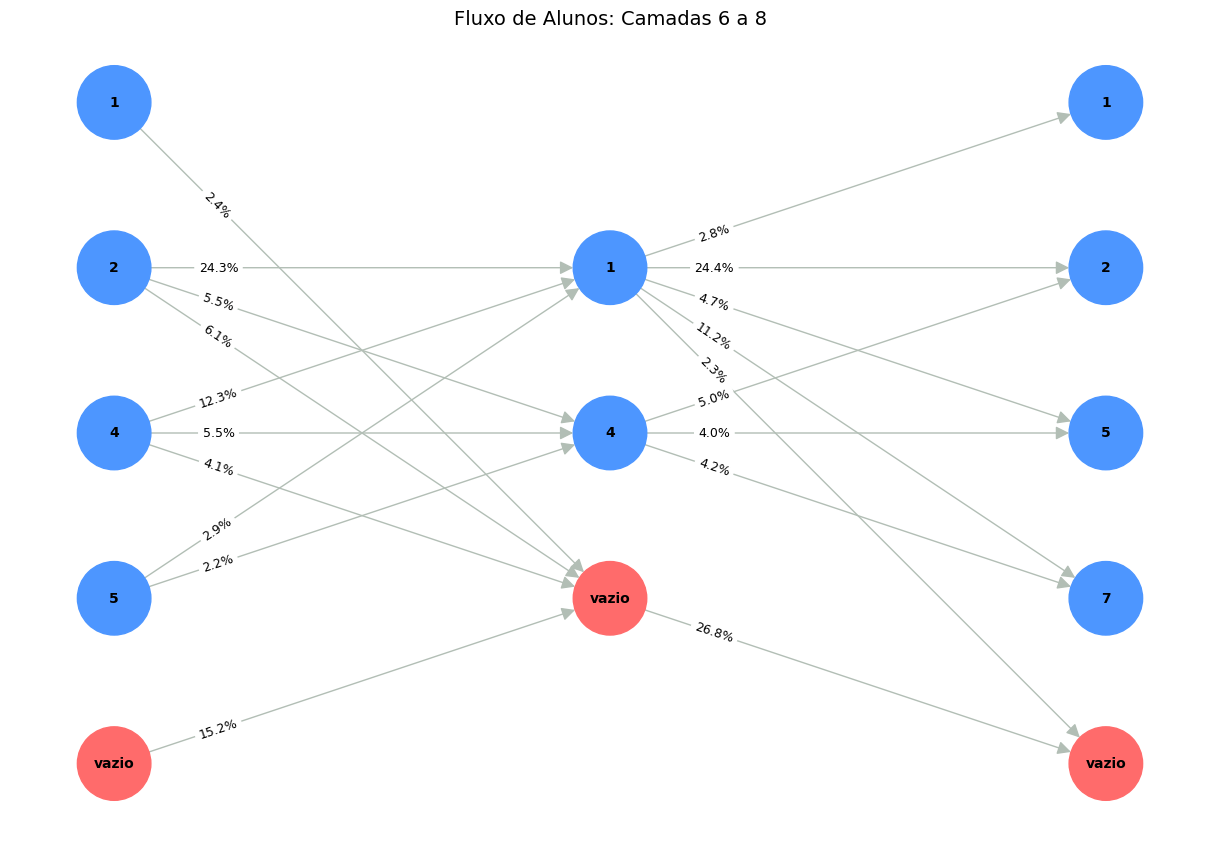

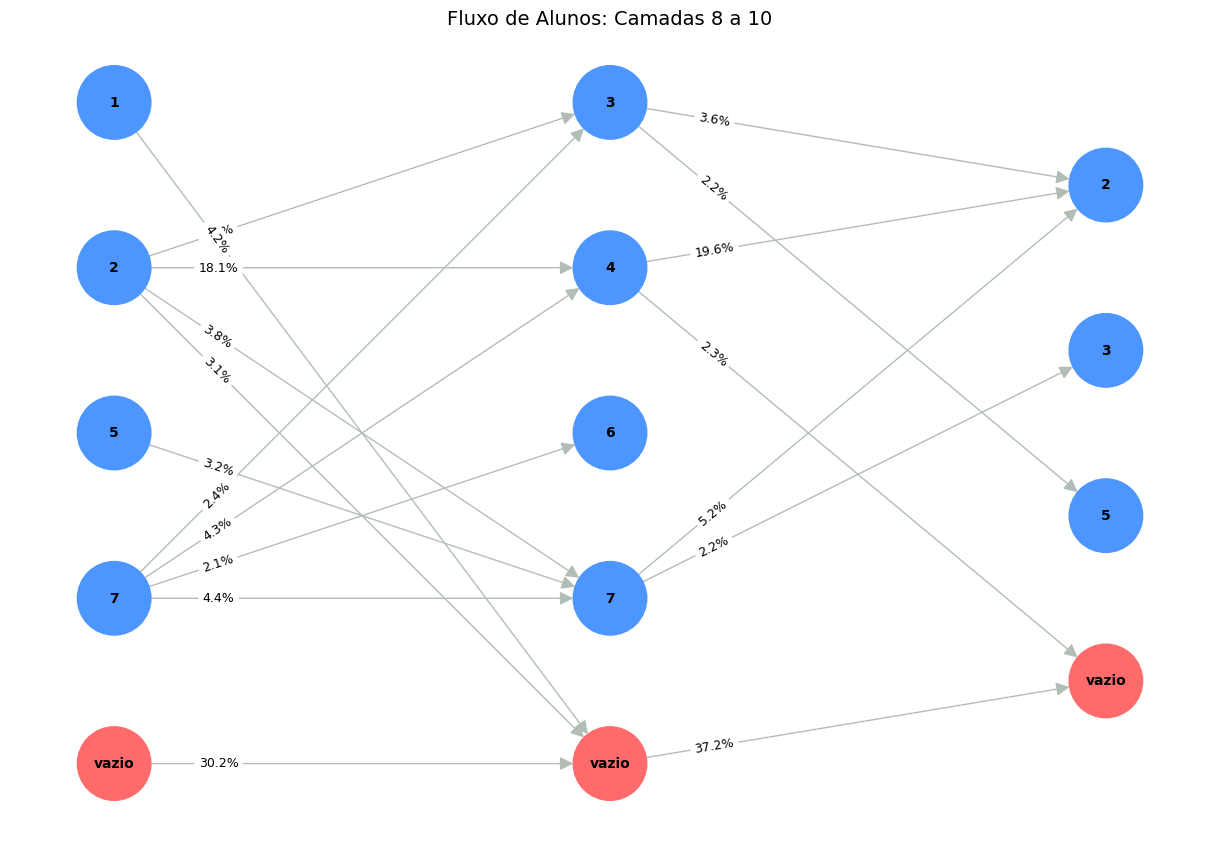

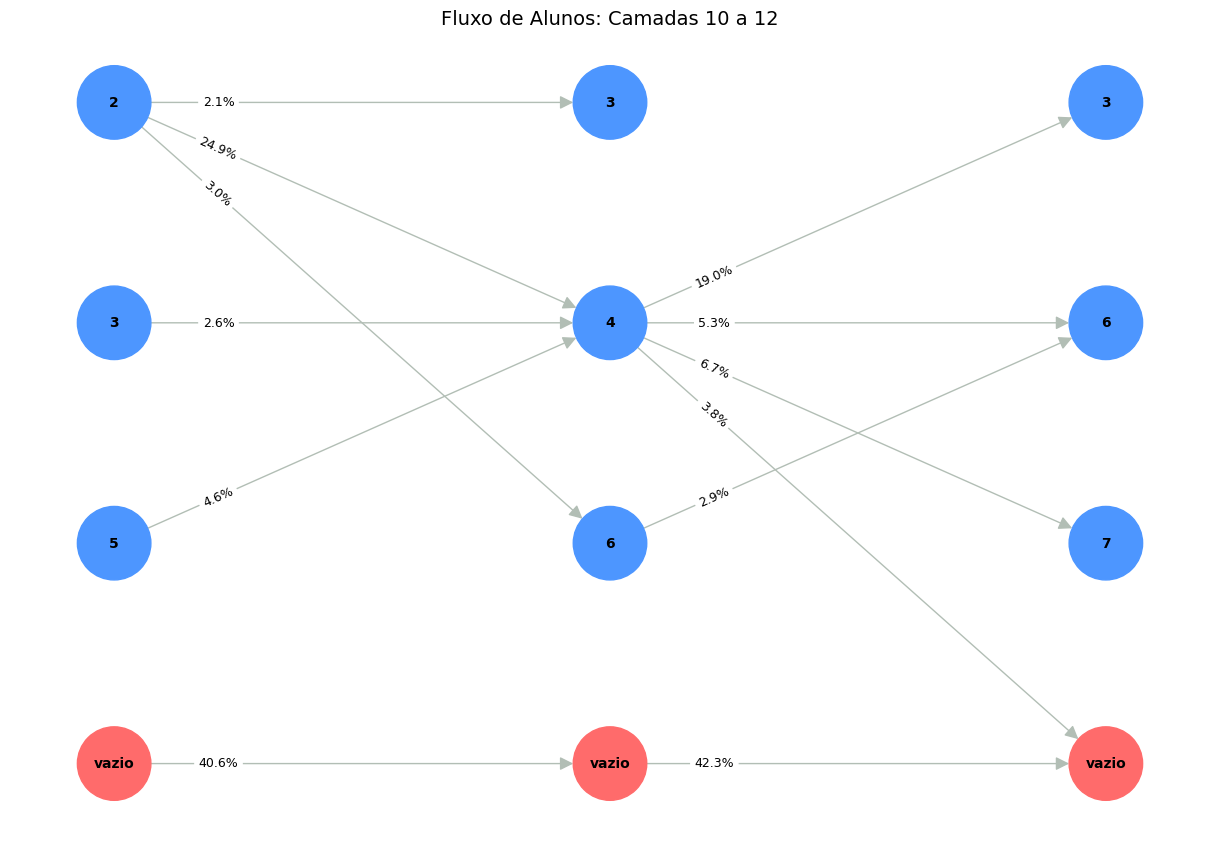

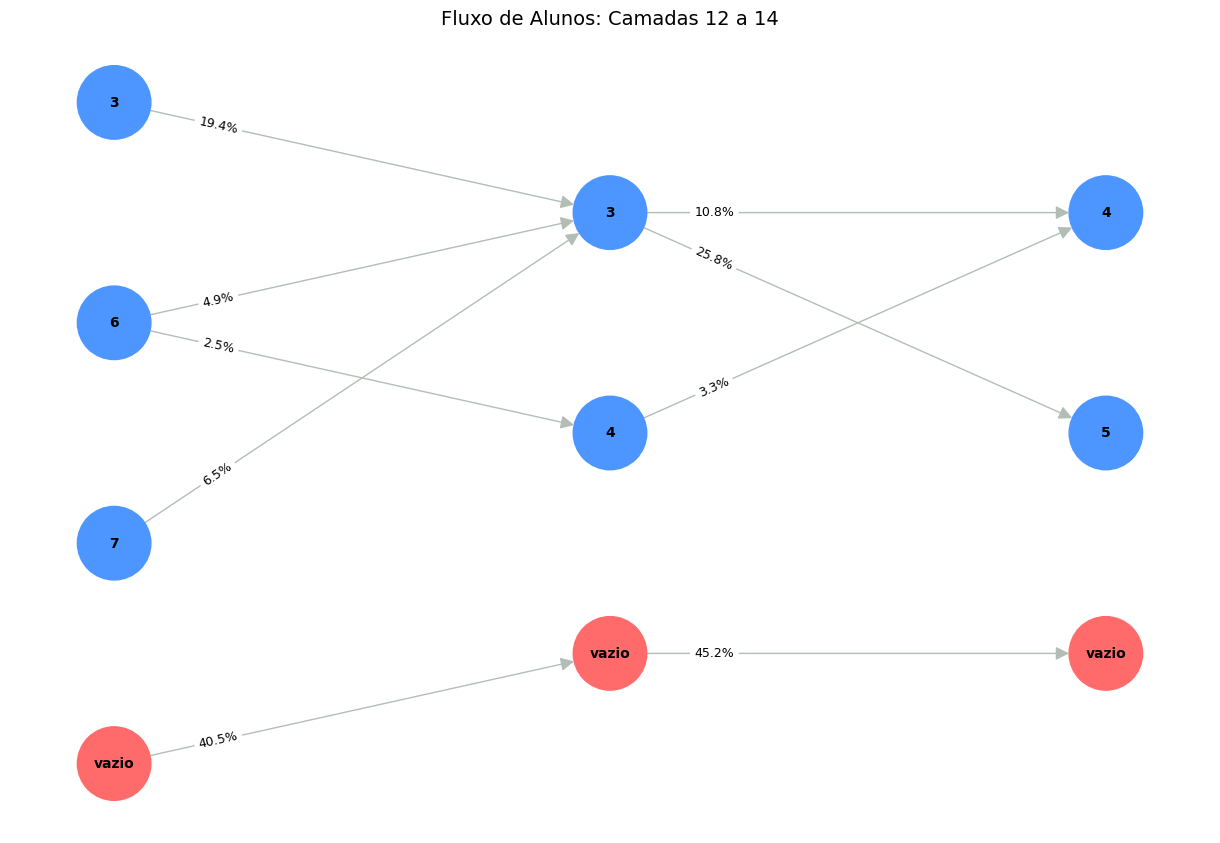

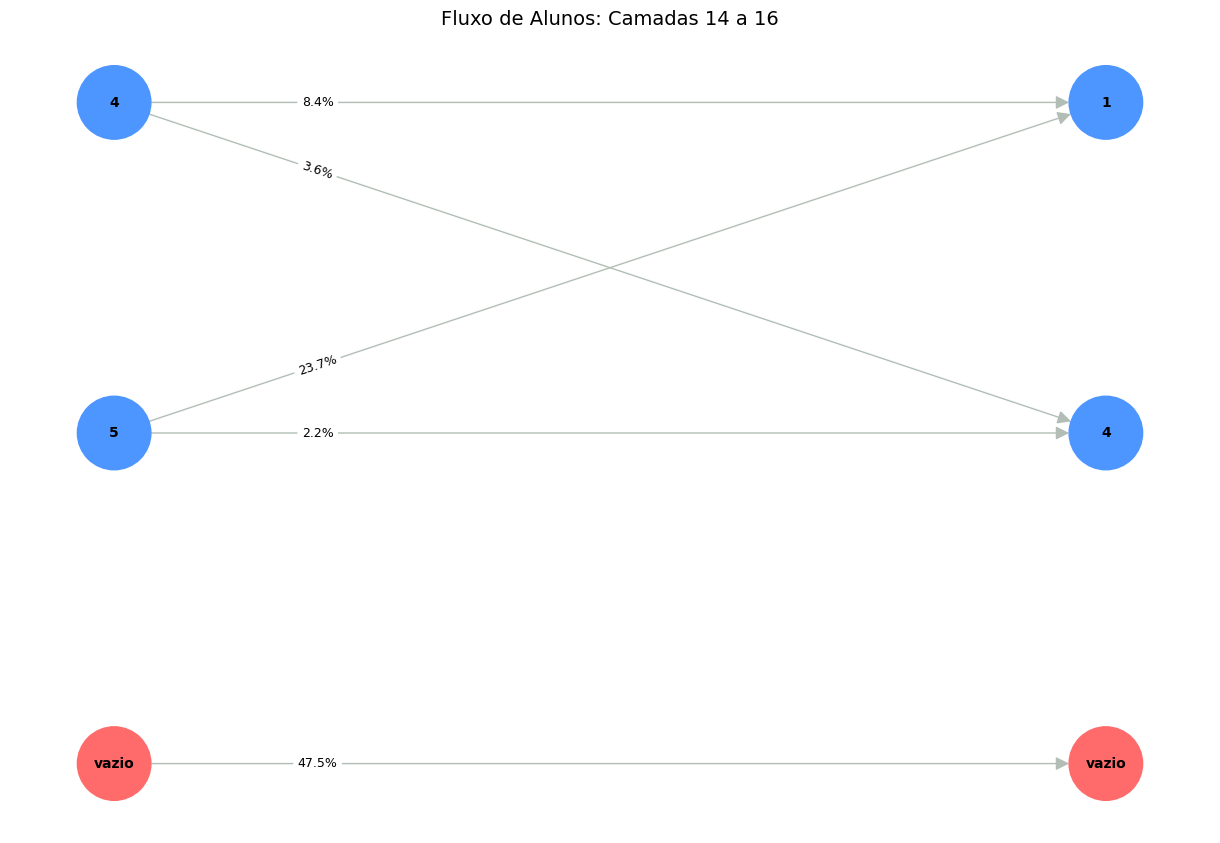

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def plotar_fluxo_final(lista_n, total_alunos, c_ini, c_fim):
    G_sub = nx.DiGraph()

    for registro in lista_n:
        transicao, contador, tempo_destino = registro

        if c_ini < tempo_destino <= c_fim:
            u = (transicao[0], tempo_destino - 1)
            v = (transicao[1], tempo_destino)
            prob = (contador / total_alunos) * 100

            # Seu filtro de 2% ajuda muito na limpeza
            if prob > 2:
                G_sub.add_edge(u, v, label=f"{prob:.1f}%")

    if not G_sub.edges:
        return

    pos = {}
    nodos_por_tempo = {}
    for n in G_sub.nodes:
        t = n[1]
        nodos_por_tempo.setdefault(t, []).append(n)

    for t, nodes in nodos_por_tempo.items():
        nodes_sorted = sorted(nodes, key=lambda x: str(x[0]))
        for j, node in enumerate(nodes_sorted):
            pos[node] = (t, -(j - len(nodes_sorted) / 2) * 3.0) # Aumentado para 3.0 para dar mais espaço vertical

    plt.figure(figsize=(12, 8))
    node_colors = ["#FF6B6B" if n[0] == 'vazio' else "#4D96FF" for n in G_sub.nodes]

    # Desenho do Grafo com curvatura aumentada
    nx.draw(
        G_sub, pos,
        with_labels=True,
        labels={n: str(n[0]) for n in G_sub.nodes},
        node_size=2800,
        node_color=node_colors,
        edge_color="#B2BEB5",
        font_size=10,
        font_weight='bold',
        arrowsize=20,

    )

    # Ajuste dos rótulos (Labels)
    edge_labels = nx.get_edge_attributes(G_sub, 'label')
    nx.draw_networkx_edge_labels(G_sub, pos, edge_labels=edge_labels, font_size=9, label_pos=0.2)

    plt.title(f"Fluxo de Alunos: Camadas {c_ini} a {c_fim}", fontsize=14)
    plt.axis('off')
    plt.show()

# Execução
dados = listas_processadas[14][1].listaN
total_alunos_fixo = 2165

# Plotando de 2 em 2 como solicitado
for i in range(0, 16, 2):
    plotar_fluxo_final(dados, total_alunos_fixo, i, i + 2)